<a href="https://www.kaggle.com/code/vladosht/simple-stock-pricing-model?scriptVersionId=310593316" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

This notebook will present a model which attempts to make individual estimates whether a stock is overvalued or not. It is based on the fundamental financial data of 3000+ public companies, which report to the SEC and which are currently traded on US stock exchanges.

DISCLAIMER: The results of this model **must not** in any way be interpreted as financial advice. It is intended for research purposes only and no investment decisions must be made based on it.

In [1]:
import json, torch
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
from datetime import datetime, timedelta
from sklearn import linear_model, preprocessing
from joblib import Parallel, delayed

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print('Torch threads:',torch.get_num_threads())
print(torch.ones(1, device=device),device)

Torch threads: 2
tensor([1.]) cpu


The model will be based on the following features and labels, taken from the SEC fundamentals dataset:

In [3]:
ml_features = ['Assets','Liabilities','NetCashOperating_ttm']
ml_label = 'price'
keys = ['snapshot','cik','date']
window_size = 12*3 #in number of snapshots

The model is called "simple", because it is rooted in this very basic assumption:  
Market_Capitalization = ( Assets \* asset_multiplier - Liabilities + NetCashOperating_ttm \* cash_multiplier ) \* hype + bias  
The business logic behind this formula is that the market capitalization of a company is dependent on its current static value (its equity) and its future cashflows. The following considerations apply:  
1. We assume the total assets of an individual company should never be taken at the nominal value that appears on the balance sheet, because they often contain a significant amount of "intangible" assets, for which it is notoriously difficult to arrive at a fair value. Therefore, we discount them with an asset_multiplier.
2. Liabilities, on the other hand, can be taken at nominal value, because it is a rare event for any kind of debt, accounts payable or the like, to be written off.
3. Then, the cash flows from operating activities can be modeled as a [perpetuity](https://en.wikipedia.org/wiki/Perpetuity). This is inspired by the idea for a [Steady State Cash Flow Model](https://www.google.com/search?q=%22Steady+State+Cash+Flow+Model%22) where we attempt to estimate the fair value of a company on the assumption that its business behaves the same way for the foreseeable future. In essence, we again discount the NetCashOperating_ttm with a cash_multiplier. We use the Trailing Twelve Months (ttm) value here, and not the quarterly value, because it smoothens any seasonalities and makes the model less erratic.
4. All of the above is multiplied by a "hype" parameter, which is the premium or penalty that the market gives to the total value of the company.
5. The bias further fine-tunes the company value to its market capitalization.  

However, it seems difficult to obtain freely available historic market capitalization data for individual companies. It turns out this is not really necessary. It is much easier to obtain historic prices and modelling the share price directly is even simpler.  
We do this by maximizing the **correlation coefficient** between our formula and the price. In short, we try to find such asset_multiplier and cash_multiplier parameters, for which the correlation between ( Assets \* asset_multiplier - Liabilities + NetCashOperating_ttm \* cash_multiplier ) and the price is equal to 1.

In [4]:
# We use this dataset to provide ticker descriptions later on.
with open('/kaggle/input/sec-edgar-cik-ticker-exchange/company_tickers_exchange.json',mode='rt') as f:
    jfile = json.load(f)
tickers = pd.DataFrame(columns=jfile['fields'],data=jfile['data'],dtype=str)
tickers = tickers[tickers['exchange']!='OTC'].dropna() #leave only tickers traded on an exchange
tickers['exchange'] = tickers['exchange'].str.upper().str.strip()
tickers['cik'] = tickers['cik'].str.zfill(10)
tickers['len'] = 4
tickers.loc[tickers[tickers['ticker'].str.contains('-')].index,'len'] += 1
tickers['ticker'] = tickers.apply(lambda row: str(row.ticker[:row.len]),axis='columns').str.rstrip().str.rstrip('-').str.upper()
tickers = tickers.sort_values(by=['cik','exchange','ticker']).drop_duplicates(subset=['cik'],keep='last').set_index('cik').drop(columns=['len'])
tickers

,name,ticker,exchange
cik,,,
0000001750,AAR CORP,AIR,NYSE
0000001800,ABBOTT LABORATORIES,ABT,NYSE
0000002098,ACME UNITED CORP,ACU,NYSE
0000002178,"ADAMS RESOURCES & ENERGY, INC.",AE,NYSE
0000002186,BK Technologies Corp,BKTI,NYSE
...,...,...,...
0001984060,Atlas Energy Solutions Inc.,AESI,NYSE
0001990550,"Ambrx Biopharma, Inc.",AMAM,NASDAQ
0001993004,"NorthWestern Energy Group, Inc.",NWE,NASDAQ


In [5]:
prices = pd.read_csv('/kaggle/input/monthly-us-stock-prices/prices.csv').rename(columns={'date':'snapshot'}).dropna()
prices['snapshot'] = pd.to_datetime(prices['snapshot']).dt.date
prices

,ticker,exchange,snapshot,price
0,A,NYSE - Delayed Quote,2010-02-01,20.05
1,A,NYSE - Delayed Quote,2010-03-01,22.50
2,A,NYSE - Delayed Quote,2010-04-01,24.60
3,A,NYSE - Delayed Quote,2010-05-01,25.94
4,A,NYSE - Delayed Quote,2010-06-01,23.15
...,...,...,...,...
604455,ZYME,NasdaqGS - Delayed Quote,2025-09-01,14.81
604456,ZYME,NasdaqGS - Delayed Quote,2025-10-01,17.08
604457,ZYME,NasdaqGS - Delayed Quote,2025-11-01,19.08
604458,ZYME,NasdaqGS - Delayed Quote,2025-12-01,26.71


In [6]:
raw_snapshots = pd.read_csv('/kaggle/input/fundamental-data-from-sec-xbrl-companyfacts-zip/snapshots.csv',dtype={'cik':str})
for i in ['snapshot','date']:
    raw_snapshots[i] = pd.to_datetime(raw_snapshots[i]).dt.date
raw_snapshots['timediff'] = pd.to_timedelta((raw_snapshots['snapshot'] - raw_snapshots['date'])).dt.days
raw_snapshots

,snapshot,cik,date,Assets,Revenue,COGS,GrossProfit,Equity,NetCashOperating,NetCashFinancing,...,Revenue_ttm,GrossProfit_ttm,NetCashOperating_ttm,NetCashFinancing_ttm,Earnings_ttm,ticker,exchange,PublicFloat,Employees,timediff
0,2012-01-01,0000001750,2011-11-30,1.821612,0.482000,0.403400,0.078600,0.863948,0.030412,-0.006559,...,1.920517,0.322328,0.083588,0.026485,0.073512,AIR,NYSE,0.934568,NaN,32
1,2012-01-01,0000001800,2011-09-30,59.628176,9.816682,3.973250,5.843432,24.603800,3.054430,-2.668122,...,38.441677,22.693948,9.885247,-4.831951,4.550604,ABT,NYSE,69.683329,NaN,93
2,2012-01-01,0000001961,2011-09-30,NaN,0.000000,0.000000,0.000000,NaN,-0.000067,0.000150,...,0.000188,0.000169,-0.000528,0.000456,-0.000968,NaN,NaN,NaN,NaN,93
3,2012-01-01,0000002034,2011-09-30,0.292355,0.101317,0.082798,0.018519,0.161372,0.005913,-0.001570,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,93
4,2012-01-01,0000002098,2011-09-30,0.055344,0.019036,0.012396,0.006640,0.027561,0.003165,-0.000680,...,0.093494,0.033742,-0.003533,0.008428,0.004770,ACU,NYSE,NaN,NaN,93
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1106546,2026-04-04,0002098712,2025-12-31,0.000156,0.000000,NaN,NaN,-0.000020,-0.000004,0.000078,...,NaN,NaN,NaN,NaN,NaN,GIX,NASDAQ,0.000000,NaN,94
1106547,2026-04-04,0002099093,2025-12-31,0.000344,NaN,NaN,NaN,-0.000020,-0.000010,0.000011,...,NaN,NaN,NaN,NaN,NaN,HCIC,NASDAQ,0.241500,NaN,94
1106548,2026-04-04,0002099656,2025-12-31,0.000307,NaN,NaN,NaN,-0.000026,NaN,0.000025,...,NaN,NaN,NaN,NaN,NaN,HLXC,NASDAQ,0.169270,NaN,94
1106549,2026-04-04,0002099906,2025-12-31,0.000391,NaN,NaN,NaN,-0.000075,NaN,0.000000,...,NaN,NaN,NaN,NaN,NaN,AACO,NASDAQ,0.000000,NaN,94


Below we merge the fundamental data with the price data and do some dataset cleaning to maximize model performance. The datasets themselves are documented on their respective pages and you can refer to them for further insights about their structure.

In [7]:
snapshots = pd.merge(raw_snapshots,prices,on=['ticker','snapshot'],suffixes=('','_yahoo'),how='left')

# The key date (snapshot date) must always be later than the period-end date. We enforce this
# per cik using the timediff column - it must be positive for all records of a cik.
# We also ensure a window_size number of snapshots of historic data is available for each cik.
snapshots = snapshots[keys +['ticker'] + ml_features + [ml_label] + ['timediff']]
valid_ciks = snapshots.dropna().groupby(by='cik')['timediff'].aggregate(['min','count'])
valid_ciks = valid_ciks[(valid_ciks['min']>0)&(valid_ciks['count']>window_size)]
snapshots = snapshots.set_index(keys)
snapshots = snapshots.loc[(slice(None),valid_ciks.index.to_list()),:].sort_index().drop(columns='timediff')

# Ciks that have assets close to zero cause problems during training. We remove them
zero_asset_ciks = list(snapshots[snapshots['Assets'].fillna(0.0).abs()<1e-3].reset_index()['cik'].unique())
zero_asset_ciks = snapshots.loc[(slice(None),zero_asset_ciks),:].index
snapshots = snapshots.drop(index=zero_asset_ciks)

# There are several ciks, that have reported wrong data 1000 times larger than actual.
# They apparently never submitted a correction.
# This data disrupts the training and we remove the whole ciks.
asset_outliers = snapshots.groupby(by='cik')['Assets'].aggregate(['min','max'])
asset_outliers = asset_outliers['min']/asset_outliers['max']
asset_outliers = asset_outliers.sort_values().fillna(0.0)
asset_outliers = list(asset_outliers[asset_outliers<1e-3].reset_index()['cik'].unique())
asset_outliers = snapshots.loc[(slice(None),asset_outliers),:].index
snapshots = snapshots.drop(index=asset_outliers)

# There are 100+ ciks that report too infrequently, i.e. less than 4 times a year.
# These are mostly foreign (non-US) entities that nevertheless trade on US exchanges.
# Whatever the cause, ciks that report less often than 4 times a year distort the model and we
# remove them. We determine the reporting frequency by the unique Asset values reported per year.
too_few_reports = snapshots[['Assets']].dropna()
too_few_reports['year'] = pd.to_datetime(too_few_reports.index.get_level_values(0)).year
too_few_reports = too_few_reports.groupby(by=['cik','year'])['Assets'].nunique().groupby('cik').max()
too_few_reports = snapshots.loc[(slice(None),too_few_reports[too_few_reports<4].index),:].index
snapshots = snapshots.drop(index=too_few_reports)

snapshots

ticker     Assets  Liabilities  \
snapshot   cik        date                                        
2012-01-01 0000001750 2011-11-30    AIR   1.821612     0.957664   
           0000001800 2011-09-30    ABT  59.628176    35.024376   
           0000002098 2011-09-30    ACU   0.055344     0.027783   
           0000002488 2011-10-01    AMD   5.236000     3.492000   
           0000002969 2011-09-30    APD  14.290700     8.494900   
...                                 ...        ...          ...   
2026-04-04 0001905956 2025-12-31    TGL   0.024230     0.006274   
           0001906324 2025-12-28   QDEL   5.769300     3.848800   
           0001907982 2025-12-31   QBTS   0.915813     0.063583   
           0001914605 2025-12-31   ECBK   1.605653     1.433719   
           0001915657 2025-12-31   DINO  16.510000     7.326000   

                                  NetCashOperating_ttm  price  
snapshot   cik        date                                     
2012-01-01 0000001750 2011-11-30              0.083588  19.17  
           0000001800 2011-09-30              9.885247  26.98  
           0000002098 2011-09-30             -0.003533   9.50  
           0000002488 2011-10-01             -0.018000   5.40  
           0000002969 2011-09-30              1.753200  78.81  
...                                                ...    ...  
2026-04-04 0001905956 2025-12-31             -0.012631    NaN  
           0001906324 2025-12-28              0.105200    NaN  
           0001907982 2025-12-31             -0.071982    NaN  
           0001914605 2025-12-31              0.009220    NaN  
           0001915657 2025-12-31              1.315000    NaN  

[439221 rows x 5 columns]

Machine learning algorithms in general cannot handle NaN values. The data we feed into our algorithm later must not only be free of NaNs, but it must also be symmetrical, i.e., for each cik there must be the same number of snapshots in the dataset. This is of course not the case in the raw data, so we create rows where they do not exist for a particular cik/snapshot combination. Then we replace all NaNs with zero, but we do retain information in a new column (is_created) whether a row was artificially created or not.

In [8]:
ml_input_df = snapshots.dropna().copy()
ml_input_df['is_created'] = False
unique_snapshot_dates = ml_input_df.index.get_level_values(0).unique().sort_values().to_series()
unique_ciks = ml_input_df.index.get_level_values(1).unique().sort_values().to_series()
print("There are {} unique snapshots and {} unique ciks for a total of {} records.".format(
    len(unique_snapshot_dates),len(unique_ciks),len(unique_snapshot_dates)*len(unique_ciks)))

ml_input_df = pd.merge(pd.merge(unique_snapshot_dates, unique_ciks, how='cross'),
                       ml_input_df[ml_features+[ml_label,'is_created']].reset_index(drop=False),how='left')
ml_input_df = ml_input_df.drop(columns=['date']).set_index(['cik','snapshot']).sort_index()
ml_input_df['is_created'] = ml_input_df['is_created'].isna()
ml_input_df = ml_input_df.fillna(0.0)
ml_input_df

There are 169 unique snapshots and 3147 unique ciks for a total of 531843 records.


Assets  Liabilities  NetCashOperating_ttm  price  \
cik        snapshot                                                          
0000001750 2012-01-01   1.821612     0.957664              0.083588  19.17   
           2012-02-01   1.821612     0.957664              0.083588  21.19   
           2012-03-01   1.821612     0.957664              0.083588  22.05   
           2012-04-01   2.220293     1.330213              0.066898  18.25   
           2012-05-01   2.220293     1.330213              0.066898  15.45   
...                          ...          ...                   ...    ...   
0001915657 2025-09-01  16.843000     7.561000              1.067000  50.88   
           2025-10-01  16.843000     7.561000              1.067000  52.34   
           2025-11-01  17.264000     7.834000              1.167000  51.60   
           2025-12-01  17.264000     7.834000              1.167000  52.91   
           2026-01-01  17.264000     7.834000              1.167000  46.08   

                       is_created  
cik        snapshot                
0000001750 2012-01-01       False  
           2012-02-01       False  
           2012-03-01       False  
           2012-04-01       False  
           2012-05-01       False  
...                           ...  
0001915657 2025-09-01       False  
           2025-10-01       False  
           2025-11-01       False  
           2025-12-01       False  
           2026-01-01       False  

[531843 rows x 5 columns]

The cell below is the heart of our machine learning model. The following is critical for the loss function we want to use - the correlation coefficient between our model formula and the price. Unfortunately the built-in PyTorch function can handle only pairs of 1d tensors, so with the help of Google's Gemini AI we re-created it to handle our multi-dimensional data.

Gemini states that: "Cosine similarity is equivalent to Pearson correlation only if the input vectors are first centered (mean is zero)". There is a quite nice CosineSimilarity class in PyTorch, so we extend it to fit our needs for a custom loss function.

From our previous [whole-market model](https://www.kaggle.com/code/vladosht/s-p-500-fundamental-data-model) we know that the market as a whole does not adjust the total assets away from their nominal value. We put this knowledge into the loss function by minimizing the ratio between total adjusted assets for all ciks and total unadjusted assets for all ciks (component market_assets_loss)

In [9]:
class MyPearsonLoss(torch.nn.CosineSimilarity):
    def forward(self, x1, x2, assets, asmul):
        
        pearson = super().forward(x1 - x1.mean(dim=self.dim, keepdim=True),
                                  x2 - x2.mean(dim=self.dim, keepdim=True))

        # If pearson = -1 -> corr = 2 (worst case)
        # If pearson =  0 -> corr = 1 (bad case)
        # If pearson =  1 -> corr = 0 (best case)
        corr = 1 - pearson

        self.correlation_loss = corr.sum() + corr.std()
        
        # The market as a whole does not adjust the total assets away from their nominal value:
        adjusted_assets = assets * 10**asmul.unsqueeze(1)
        self.market_assets_loss = (adjusted_assets.sum(dim=0) / assets.sum(dim=0) - 1).abs().sum()
        
        # We need some kind of regularization for the asset_multiplier,
        # otherwise the values become erratic and uncomparable across ciks
        self.asmul_loss = 10 * asmul.mean().abs() + asmul.std()
        
        # The total loss is just a weighted sum of the individual loss components
        total_loss = self.correlation_loss + self.market_assets_loss + 10 * self.asmul_loss
        
        return total_loss
        
    def get_param_state(self):
        """ Return a dictionary with the individual loss components """
        return { i:getattr(self,i).item() for i in dir(self) if '_loss' in i }

What follows is the actual model implementation. We need to clarify several things here:
1. We compute the asset_multiplier on per-cik basis, but the cash_multiplier is only computed on per-snapshot basis. The reasoning behind this is that it is much more logical to assume that the discount rate for the NetCashOperating_ttm is the same for all ciks on a given date, something like a common interest rate for all companies that depends not on individual companies, but on general interest and inflation levels and return-on-investment expectations of investors. This also makes the model more generalized.
2. The asset_multiplier is enforced to be always positive by exponentiating the actual parameter we are trying to find. I.e., final asset_multiplier = 10 \*\* (internal parameter)
3. The model results are returned by the get_df method, which simply takes the input dataframe and extends it with two additional columns for the asset_multiplier and cash_multiplier. It also returns a column for the computed model value. Remember, this model value only correlates well with the price, it is not equal to the price.

In [10]:
class SimplePricingModel(torch.nn.Module):
    def __init__(self, df, print_shape=True):
        super().__init__()
        self.print_shape = print_shape
        self.df          = df
        self.columns     = df.columns.to_list()
        self.columns     = { i:self.columns.index(i) for i in self.columns }
        self.ciks        = df.index.get_level_values(0).unique()
        self.len_ciks    = len(self.ciks)
        self.len_snapshots = len(df.index.get_level_values(1).unique())
        self.asmul       = torch.nn.Parameter(0.1 + torch.rand(self.len_ciks))
        self.cashmul     = torch.nn.Parameter(0.1 + torch.rand(self.len_snapshots))
        self.ml_input    = torch.nn.Buffer(torch.tensor(df[ml_features].to_numpy()).reshape(self.len_ciks,self.len_snapshots,-1))
        self.labels      = torch.nn.Buffer(torch.tensor(df[ml_label].to_numpy()).reshape(self.len_ciks,self.len_snapshots))
        if self.print_shape:
            print('Input shape:',self.ml_input.shape)
            print('Labels shape:',self.labels.shape)
            print('Asset multiplier shape:',self.asmul.shape)
            print('Cash multiplier shape:',self.cashmul.shape)
    
    def get_param_state(self):
        return { "median cashmul" : self.cashmul.median().item(), "median asmul" : (10 ** self.asmul).median().item() }

    def forward(self):
        adjusted_assets   = self.ml_input[:,:,self.columns['Assets']] * 10**self.asmul.unsqueeze(1)
        liabilities       = self.ml_input[:,:,self.columns['Liabilities']]
        adjusted_cashflow = self.ml_input[:,:,self.columns['NetCashOperating_ttm']] * self.cashmul.unsqueeze(0)
        fwd = adjusted_assets - liabilities + adjusted_cashflow
        if self.print_shape:
            print('Adjusted assets shape:', adjusted_assets.shape)     
            print('Adjusted cashflow shape:', adjusted_cashflow.shape)     
            print('Forward shape:', fwd.shape)
            self.print_shape = False
        return fwd

    def get_df(self):
        asmul = pd.Series(index=self.ciks, data = self.asmul.reshape(-1).cpu().detach().numpy()).rename('asmul')
        asmul = 10**asmul
        cashmul = self.cashmul.cpu().detach().numpy()
        cashmul = pd.Series(index=self.df.index.get_level_values(1).unique().sort_values(), data=cashmul).rename('cashmul')

        ret_df = pd.merge(self.df,asmul,left_index=True,right_index=True)
        ret_df = pd.merge(ret_df,cashmul,left_index=True,right_index=True)
        ret_df['model'] = self.forward().reshape(-1).cpu().detach().numpy()
        return ret_df

pricing_model = SimplePricingModel(ml_input_df).to(device)
pricing_model.ml_input.device

Input shape: torch.Size([3147, 169, 3])
Labels shape: torch.Size([3147, 169])
Asset multiplier shape: torch.Size([3147])
Cash multiplier shape: torch.Size([169])


device(type='cpu')

Adjusted assets shape: torch.Size([3147, 169])
Adjusted cashflow shape: torch.Size([3147, 169])
Forward shape: torch.Size([3147, 169])
Epoch [1000/6000], Loss=918.11333908
Epoch [2000/6000], Loss=917.12609130
Epoch [3000/6000], Loss=916.89790545
Epoch [4000/6000], Loss=916.77471720
Epoch [5000/6000], Loss=916.68862126
Epoch [6000/6000], Loss=916.58659753


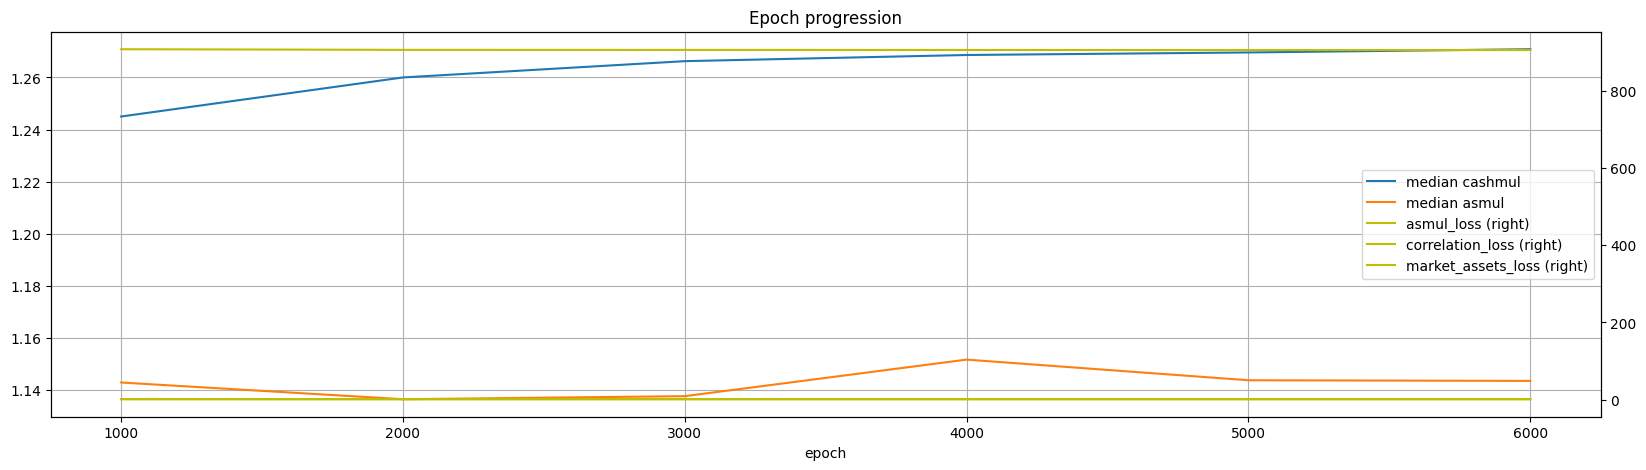

,median cashmul,median asmul,asmul_loss,correlation_loss,market_assets_loss
epoch,,,,,
1000,1.244998,1.142727,0.836363,908.674761,1.074946
2000,1.260018,1.136301,0.929724,907.003632,0.825214
3000,1.266279,1.137475,0.910368,906.884198,0.910023
4000,1.268649,1.151532,0.913179,906.747529,0.895403
5000,1.269621,1.143593,0.936352,906.511500,0.813600
6000,1.270869,1.143349,0.919493,906.561722,0.829950


In [11]:
def model_train(model, num_epochs = 6000, epoch_batch = 1000):
    optimizer = torch.optim.Adagrad(params = model.parameters(), lr = 0.2)
    loss_function = MyPearsonLoss()

    output_graphic = []

    for epoch in range(num_epochs):
        optimizer.zero_grad()
        y_pred = model.forward()
        loss = loss_function(y_pred, model.labels,
                             model.ml_input[:,:,model.columns['Assets']],
                             model.asmul)
        loss.backward()
        optimizer.step()
        if (epoch+1) % epoch_batch == 0:
            param_state = { 'epoch':epoch+1, **model.get_param_state(), **loss_function.get_param_state() }
            output_graphic.append(param_state)
            print(f"Epoch [{epoch+1}/{num_epochs}], Loss={loss.item():.8f}")

    output_graphic = pd.DataFrame(output_graphic).set_index('epoch')
    loss_cols = [ a_col for a_col in output_graphic.columns if 'loss' in str(a_col) ]
    output_graphic.drop(columns=loss_cols).plot(grid=True,figsize=(20,5),legend=True,title='Epoch progression')
    for a_loss_col in loss_cols:
        output_graphic[a_loss_col].plot(secondary_y=True,legend=True,grid=False,c='y')
    plt.show()
    return output_graphic

model_train(pricing_model)

In [12]:
model_output = pricing_model.get_df()
model_output = model_output[~model_output['is_created']].drop(columns=['is_created'])
model_output

Assets  Liabilities  NetCashOperating_ttm  price  \
cik        snapshot                                                          
0000001750 2012-01-01   1.821612     0.957664              0.083588  19.17   
           2012-02-01   1.821612     0.957664              0.083588  21.19   
           2012-03-01   1.821612     0.957664              0.083588  22.05   
           2012-04-01   2.220293     1.330213              0.066898  18.25   
           2012-05-01   2.220293     1.330213              0.066898  15.45   
...                          ...          ...                   ...    ...   
0001915657 2025-09-01  16.843000     7.561000              1.067000  50.88   
           2025-10-01  16.843000     7.561000              1.067000  52.34   
           2025-11-01  17.264000     7.834000              1.167000  51.60   
           2025-12-01  17.264000     7.834000              1.167000  52.91   
           2026-01-01  17.264000     7.834000              1.167000  46.08   

                          asmul   cashmul     model  
cik        snapshot                                  
0000001750 2012-01-01  1.002591 -1.215230  0.767088  
           2012-02-01  1.002591 -1.077360  0.778613  
           2012-03-01  1.002591 -1.003307  0.784803  
           2012-04-01  1.002591 -0.929663  0.833639  
           2012-05-01  1.002591 -0.953807  0.832024  
...                         ...       ...       ...  
0001915657 2025-09-01  0.824758  1.602837  8.040634  
           2025-10-01  0.824758  1.590330  8.027289  
           2025-11-01  0.824758  1.471087  8.121389  
           2025-12-01  0.824758  1.514211  8.171714  
           2026-01-01  0.824758  1.517291  8.175309  

[414387 rows x 7 columns]

In [13]:
# We take the computed multipliers and put them into the original dataframe "snapshots"
mul_columns = ['asmul','cashmul']
result = pd.merge(snapshots,
                  model_output.groupby(by=['snapshot','cik'])[mul_columns].mean(),
                  left_index=True, right_index=True, how='left')
result['model'] = result['asmul']*result['Assets'] - result['Liabilities'] + result['cashmul']*result['NetCashOperating_ttm']

# The model values and the prices correlate by design, so the simplest linear regression will yield
# a conversion between them.
def line_fit(a_group):
    (ticker, cik), df = a_group
    train_data = df[['model','price']].dropna()
    regressor = linear_model.LinearRegression().fit(X=train_data[['model']],y=train_data['price'])
    df['hype'] = regressor.coef_[0]
    df['bias'] = regressor.intercept_
    return df

with Parallel(n_jobs=-1) as p:
    result = pd.concat(p(delayed(line_fit)(i) for i in result.groupby(by=['ticker','cik'])))
    
result = result.reset_index().set_index(['snapshot','cik','date']).sort_index()

# Sample data: Amazon
result[result['ticker']=='AMZN'].tail(20)

,,,ticker,Assets,Liabilities,NetCashOperating_ttm,price,asmul,cashmul,model,hype,bias
snapshot,cik,date,,,,,,,,,,
2024-10-01,0001018724,2024-06-30,AMZN,554.818,318.371,177.090000,186.33,0.598306,1.621553,300.740488,0.558946,46.969301
2024-11-01,0001018724,2024-06-30,AMZN,554.818,318.371,177.090000,186.40,0.598306,1.546031,287.366285,0.558946,46.969301
2024-12-01,0001018724,2024-09-30,AMZN,584.626,325.475,193.943333,207.89,0.598306,1.822009,377.676480,0.558946,46.969301
2025-01-01,0001018724,2024-09-30,AMZN,584.626,325.475,193.943333,219.39,0.598306,1.544404,323.836877,0.558946,46.969301
2025-02-01,0001018724,2024-09-30,AMZN,584.626,325.475,193.943333,237.68,0.598306,1.624598,339.389991,0.558946,46.969301
2025-03-01,0001018724,2024-12-31,AMZN,624.894,338.924,197.114333,212.28,0.598306,1.538520,338.217852,0.558946,46.969301
2025-04-01,0001018724,2024-12-31,AMZN,624.894,338.924,197.114333,190.26,0.598306,1.364923,303.999517,0.558946,46.969301
2025-05-01,0001018724,2024-12-31,AMZN,624.894,338.924,197.114333,184.42,0.598306,1.275463,286.365665,0.558946,46.969301
2025-06-01,0001018724,2025-03-31,AMZN,643.256,337.389,199.102833,205.01,0.598306,1.407417,327.695371,0.558946,46.969301


Let's examine the distribution of the achieved correlations:

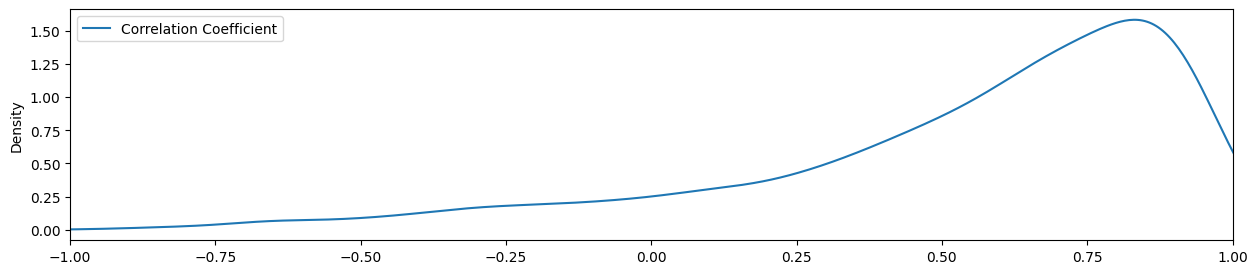

In [14]:
model_corr = result.dropna().groupby(by='cik')[[ml_label,'model']].corr().reset_index()
model_corr = model_corr[model_corr[model_corr.columns[1]]==ml_label][['cik','model']]
model_corr = model_corr.rename(columns={'model':'Correlation Coefficient'}).set_index('cik')
model_corr.plot.density(bw_method=0.2,figsize=(15,3),xlim=(-1,1))
plt.show()

It is interesting to see the development of the two multipliers over time. The cash multiplier is the same for all ciks on a given snapshot date and can probably serve as some form of valuation metric for the whole market.

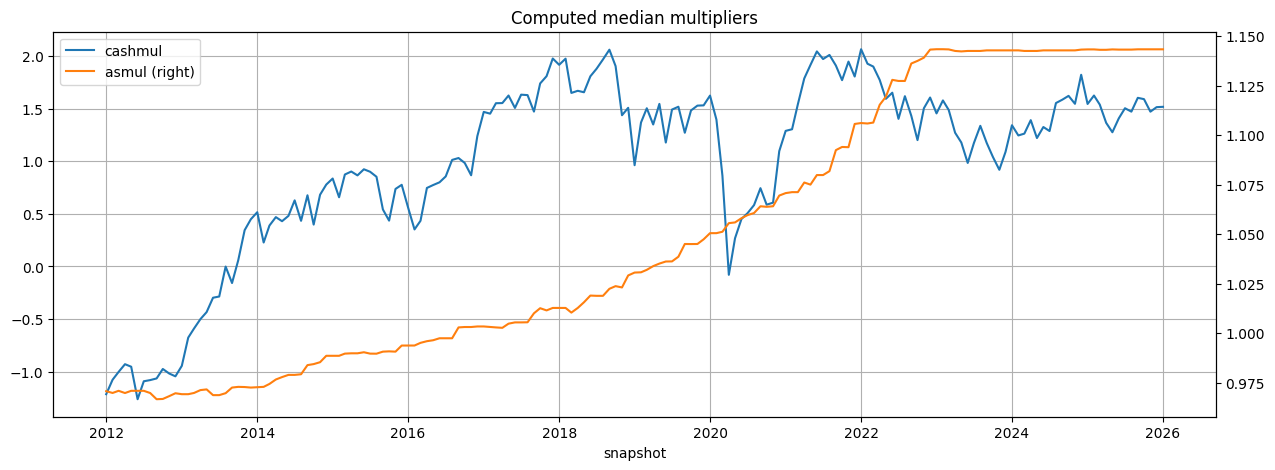

Median asset_multiplier per cik: 1.143349051475525
Median asset_multiplier per snapshot: 1.030661940574646


In [15]:
mul_graph = result.groupby(by='snapshot')[mul_columns].median()
mul_graph['cashmul'].plot(title='Computed median multipliers',figsize=(15,5),grid=True,legend=True)
mul_graph['asmul'].plot(secondary_y=True,legend=True,grid=False)
plt.show()
print("Median asset_multiplier per cik:",result['asmul'].groupby(by=['cik']).median().median())
print("Median asset_multiplier per snapshot:",result['asmul'].groupby(by=['snapshot']).median().median())

We can now output the results for later use in other models/notebooks/datasets

In [16]:
result.to_csv('/kaggle/working/pricing_model.csv.gz')

Finally, we apply the model to individual companies. I have tried to make the selection of sample tickers as varied as possible in terms of company kinds and sizes. Using the computed model values we can arrive at a fair price for each snapshot, that can be used to make some estimates if and how much the stock price corresponds to the underlying financials.

In other words, we may be able to determine if a stock is relatively over-or-undervalued, compared to its historic fundamentals.

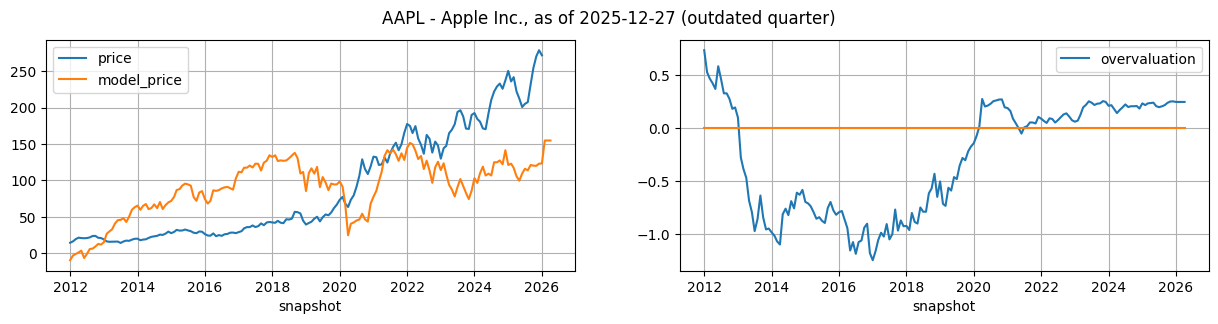

AAPL model_price = 0.617887 * (1.012796 * Assets - Liabilities + cashmul * NetCashOperating_ttm) -29.639342


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,price,asmul,cashmul,model,hype,bias,model_price,overvaluation
snapshot,cik,,,,,,,,,,,,,
2025-12-01,0000320193,2025-09-27,AAPL,359.241,285.508,111.482,278.85,1.012797,1.514211,247.137342,0.617887,-29.639342,123.063515,0.251758
2026-01-01,0000320193,2025-09-27,AAPL,359.241,285.508,111.482,271.86,1.012797,1.517291,247.480694,0.617887,-29.639342,123.275668,0.246450
2026-02-01,0000320193,2025-12-27,AAPL,379.297,291.107,135.472,NaN,1.012797,1.517291,298.594151,0.617887,-29.639342,154.857989,0.246450
2026-03-01,0000320193,2025-12-27,AAPL,379.297,291.107,135.472,NaN,1.012797,1.517291,298.594151,0.617887,-29.639342,154.857989,0.246450
2026-04-01,0000320193,2025-12-27,AAPL,379.297,291.107,135.472,NaN,1.012797,1.517291,298.594151,0.617887,-29.639342,154.857989,0.246450
2026-04-04,0000320193,2025-12-27,AAPL,379.297,291.107,135.472,NaN,1.012797,1.517291,298.594151,0.617887,-29.639342,154.857989,0.246450


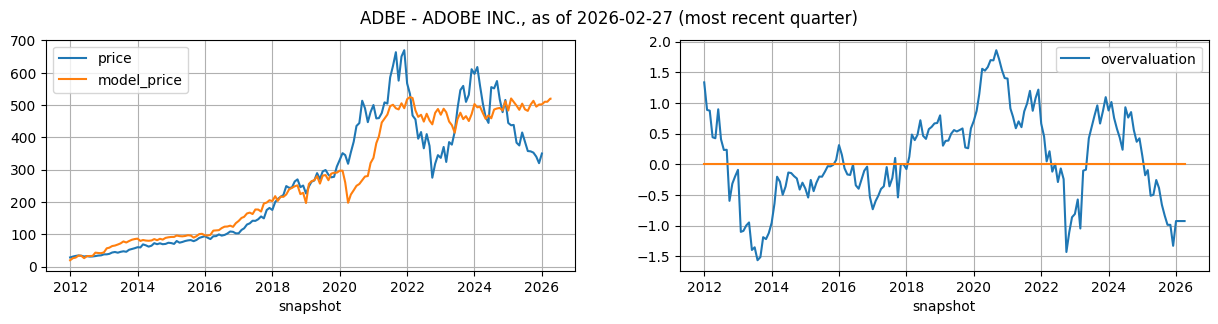

ADBE model_price = 15.463002 * (1.419214 * Assets - Liabilities + cashmul * NetCashOperating_ttm) -95.987976


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,price,asmul,cashmul,model,hype,bias,model_price,overvaluation
snapshot,cik,,,,,,,,,,,,,
2025-12-01,0000796343,2025-08-29,ADBE,28.754,16.984,9.792,320.13,1.419214,1.514211,38.651247,15.463002,-95.987976,501.676341,-1.327545
2026-01-01,0000796343,2025-08-29,ADBE,28.754,16.984,9.792,349.99,1.419214,1.517291,38.681405,15.463002,-95.987976,502.142679,-0.924185
2026-02-01,0000796343,2025-11-28,ADBE,29.496,17.873,10.031,NaN,1.419214,1.517291,39.208095,15.463002,-95.987976,510.286883,-0.924185
2026-03-01,0000796343,2025-11-28,ADBE,29.496,17.873,10.031,NaN,1.419214,1.517291,39.208095,15.463002,-95.987976,510.286883,-0.924185
2026-04-01,0000796343,2026-02-27,ADBE,29.704,18.271,10.507,NaN,1.419214,1.517291,39.827522,15.463002,-95.987976,519.865084,-0.924185
2026-04-04,0000796343,2026-02-27,ADBE,29.704,18.271,10.507,NaN,1.419214,1.517291,39.827522,15.463002,-95.987976,519.865084,-0.924185


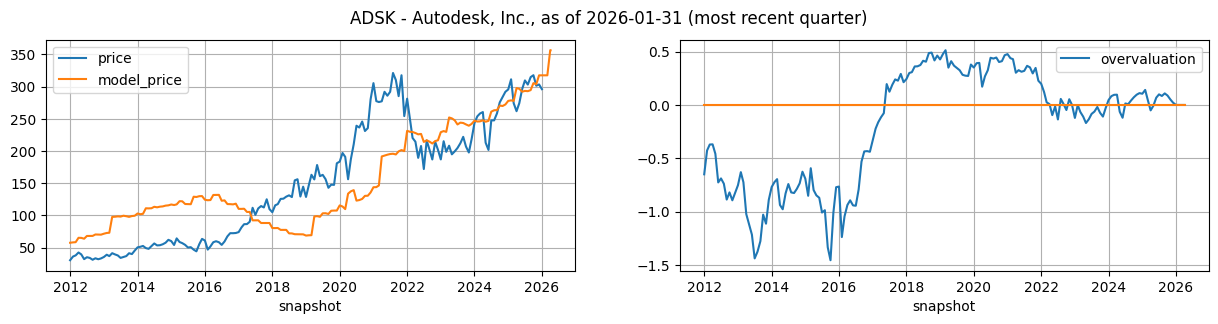

ADSK model_price = 7.359367 * (4.698581 * Assets - Liabilities + cashmul * NetCashOperating_ttm) -32.653976


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,price,asmul,cashmul,model,hype,bias,model_price,overvaluation
snapshot,cik,,,,,,,,,,,,,
2025-12-01,0000769397,2025-10-31,ADSK,11.198,8.305,2.155,303.34,4.698581,1.514211,47.572837,7.359367,-32.653976,317.451984,0.020651
2026-01-01,0000769397,2025-10-31,ADSK,11.198,8.305,2.155,296.01,4.698581,1.517291,47.579474,7.359367,-32.653976,317.500829,-0.000000
2026-02-01,0000769397,2025-10-31,ADSK,11.198,8.305,2.155,NaN,4.698581,1.517291,47.579474,7.359367,-32.653976,317.500829,-0.000000
2026-03-01,0000769397,2025-10-31,ADSK,11.198,8.305,2.155,NaN,4.698581,1.517291,47.579474,7.359367,-32.653976,317.500829,-0.000000
2026-04-01,0000769397,2026-01-31,ADSK,12.467,9.422,2.452,NaN,4.698581,1.517291,52.875609,7.359367,-32.653976,356.477029,-0.000000
2026-04-04,0000769397,2026-01-31,ADSK,12.467,9.422,2.452,NaN,4.698581,1.517291,52.875609,7.359367,-32.653976,356.477029,-0.000000


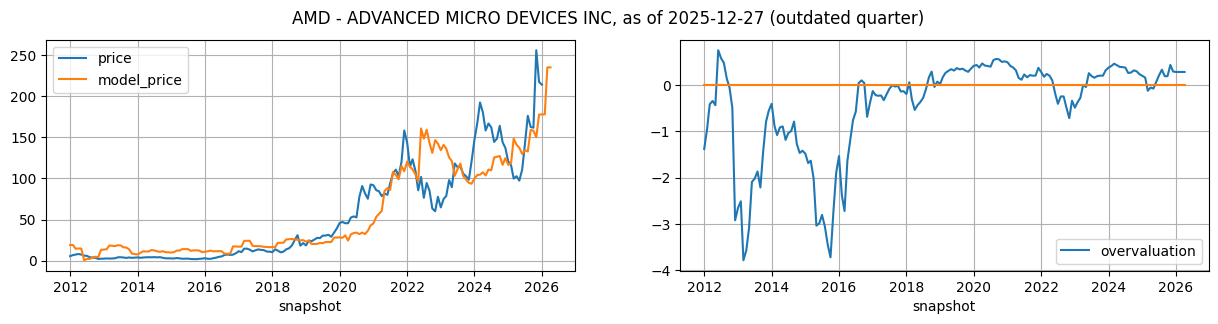

AMD model_price = 13.776721 * (0.201649 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +52.243751


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,price,asmul,cashmul,model,hype,bias,model_price,overvaluation
snapshot,cik,,,,,,,,,,,,,
2025-12-01,0000002488,2025-09-27,AMD,76.891,16.101,6.408,217.53,0.201649,1.514211,9.107066,13.776721,52.243751,177.709255,0.297855
2026-01-01,0000002488,2025-09-27,AMD,76.891,16.101,6.408,214.16,0.201649,1.517291,9.126802,13.776721,52.243751,177.981152,0.289082
2026-02-01,0000002488,2025-09-27,AMD,76.891,16.101,6.408,NaN,0.201649,1.517291,9.126802,13.776721,52.243751,177.981152,0.289082
2026-03-01,0000002488,2025-12-27,AMD,76.926,13.927,7.709,NaN,0.201649,1.517291,13.281855,13.776721,52.243751,235.224159,0.289082
2026-04-01,0000002488,2025-12-27,AMD,76.926,13.927,7.709,NaN,0.201649,1.517291,13.281855,13.776721,52.243751,235.224159,0.289082
2026-04-04,0000002488,2025-12-27,AMD,76.926,13.927,7.709,NaN,0.201649,1.517291,13.281855,13.776721,52.243751,235.224159,0.289082


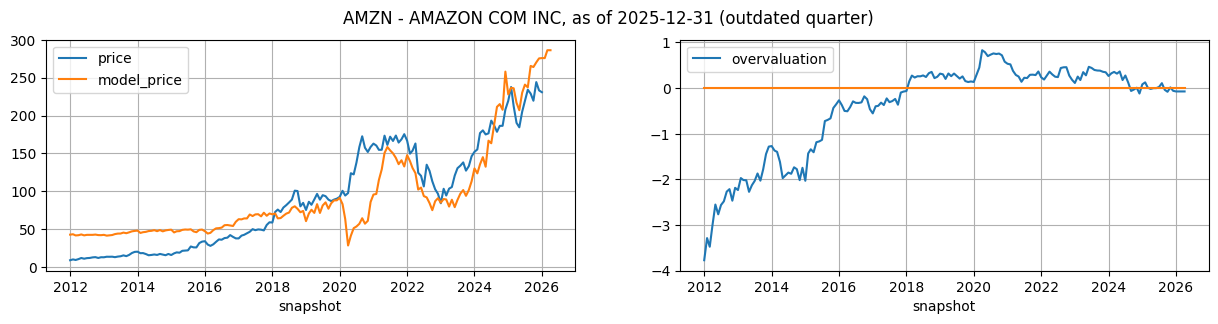

AMZN model_price = 0.558946 * (0.598306 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +46.969301


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,price,asmul,cashmul,model,hype,bias,model_price,overvaluation
snapshot,cik,,,,,,,,,,,,,
2025-12-01,0001018724,2025-09-30,AMZN,727.921,358.290,219.100167,233.22,0.598306,1.514211,408.993111,0.558946,46.969301,275.574559,-0.058815
2026-01-01,0001018724,2025-09-30,AMZN,727.921,358.290,219.100167,230.82,0.598306,1.517291,409.667916,0.558946,46.969301,275.951739,-0.072678
2026-02-01,0001018724,2025-09-30,AMZN,727.921,358.290,219.100167,NaN,0.598306,1.517291,409.667916,0.558946,46.969301,275.951739,-0.072678
2026-03-01,0001018724,2025-12-31,AMZN,818.042,406.977,227.923167,NaN,0.598306,1.517291,428.287876,0.558946,46.969301,286.359300,-0.072678
2026-04-01,0001018724,2025-12-31,AMZN,818.042,406.977,227.923167,NaN,0.598306,1.517291,428.287876,0.558946,46.969301,286.359300,-0.072678
2026-04-04,0001018724,2025-12-31,AMZN,818.042,406.977,227.923167,NaN,0.598306,1.517291,428.287876,0.558946,46.969301,286.359300,-0.072678


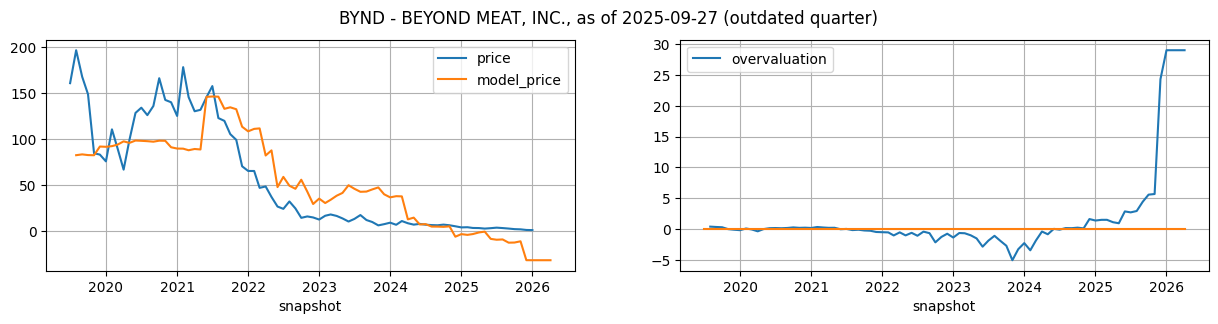

BYND model_price = 102.397901 * (1.689551 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +25.750697


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,price,asmul,cashmul,model,hype,bias,model_price,overvaluation
snapshot,cik,,,,,,,,,,,,,
2025-12-01,0001655210,2025-09-27,BYND,0.599669,1.383734,-0.12709,0.982,1.689552,1.514211,-0.563003,102.397901,25.750697,-31.899657,24.330749
2026-01-01,0001655210,2025-09-27,BYND,0.599669,1.383734,-0.12709,0.820,1.689552,1.517291,-0.563395,102.397901,25.750697,-31.939738,29.033659
2026-02-01,0001655210,2025-09-27,BYND,0.599669,1.383734,-0.12709,NaN,1.689552,1.517291,-0.563395,102.397901,25.750697,-31.939738,29.033659
2026-03-01,0001655210,2025-09-27,BYND,0.599669,1.383734,-0.12709,NaN,1.689552,1.517291,-0.563395,102.397901,25.750697,-31.939738,29.033659
2026-04-01,0001655210,2025-09-27,BYND,0.599669,1.383734,-0.12709,NaN,1.689552,1.517291,-0.563395,102.397901,25.750697,-31.939738,29.033659
2026-04-04,0001655210,2025-09-27,BYND,0.599669,1.383734,-0.12709,NaN,1.689552,1.517291,-0.563395,102.397901,25.750697,-31.939738,29.033659


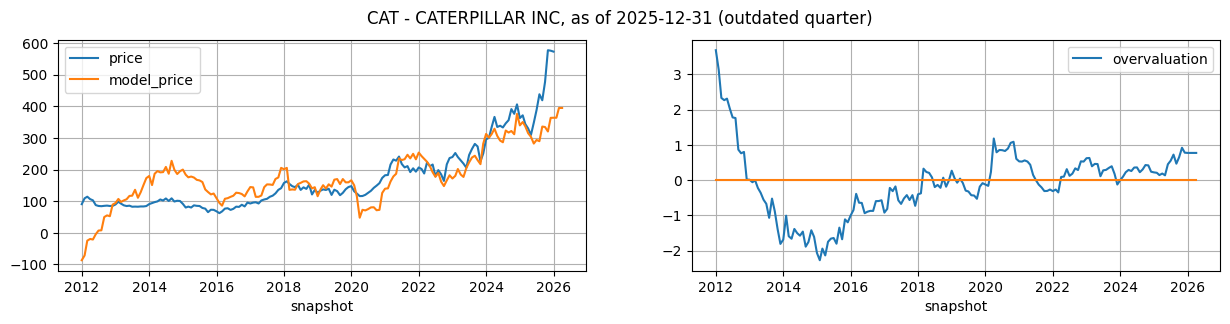

CAT model_price = 10.389847 * (1.414161 * Assets - Liabilities + cashmul * NetCashOperating_ttm) -436.036909


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,price,asmul,cashmul,model,hype,bias,model_price,overvaluation
snapshot,cik,,,,,,,,,,,,,
2025-12-01,0000018230,2025-09-30,CAT,93.722,73.063,11.541,575.76,1.414161,1.514211,76.950536,10.389847,-436.036909,363.467378,0.779968
2026-01-01,0000018230,2025-09-30,CAT,93.722,73.063,11.541,572.87,1.414161,1.517291,76.986081,10.389847,-436.036909,363.836685,0.772954
2026-02-01,0000018230,2025-09-30,CAT,93.722,73.063,11.541,NaN,1.414161,1.517291,76.986081,10.389847,-436.036909,363.836685,0.772954
2026-03-01,0000018230,2025-12-31,CAT,98.585,77.267,11.739,NaN,1.414161,1.517291,79.959571,10.389847,-436.036909,394.730792,0.772954
2026-04-01,0000018230,2025-12-31,CAT,98.585,77.267,11.739,NaN,1.414161,1.517291,79.959571,10.389847,-436.036909,394.730792,0.772954
2026-04-04,0000018230,2025-12-31,CAT,98.585,77.267,11.739,NaN,1.414161,1.517291,79.959571,10.389847,-436.036909,394.730792,0.772954


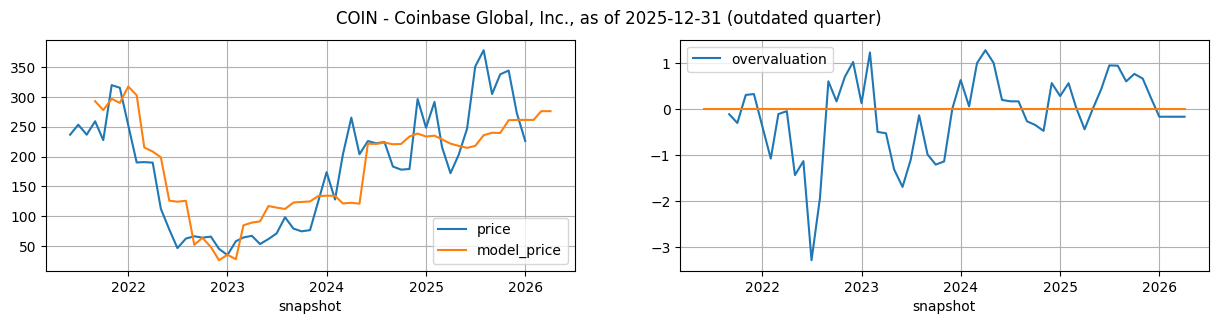

COIN model_price = 13.298988 * (1.017229 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +23.411153


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,price,asmul,cashmul,model,hype,bias,model_price,overvaluation
snapshot,cik,,,,,,,,,,,,,
2025-12-01,0001679788,2025-09-30,COIN,31.351367,15.328143,0.872941,272.82,1.017229,1.514211,17.885185,13.298988,23.411153,261.266009,0.242717
2026-01-01,0001679788,2025-09-30,COIN,31.351367,15.328143,0.872941,226.14,1.017229,1.517291,17.887873,13.298988,23.411153,261.301764,-0.169358
2026-02-01,0001679788,2025-09-30,COIN,31.351367,15.328143,0.872941,NaN,1.017229,1.517291,17.887873,13.298988,23.411153,261.301764,-0.169358
2026-03-01,0001679788,2025-12-31,COIN,29.671832,14.878774,2.426383,NaN,1.017229,1.517291,18.985794,13.298988,23.411153,275.903003,-0.169358
2026-04-01,0001679788,2025-12-31,COIN,29.671832,14.878774,2.426383,NaN,1.017229,1.517291,18.985794,13.298988,23.411153,275.903003,-0.169358
2026-04-04,0001679788,2025-12-31,COIN,29.671832,14.878774,2.426383,NaN,1.017229,1.517291,18.985794,13.298988,23.411153,275.903003,-0.169358


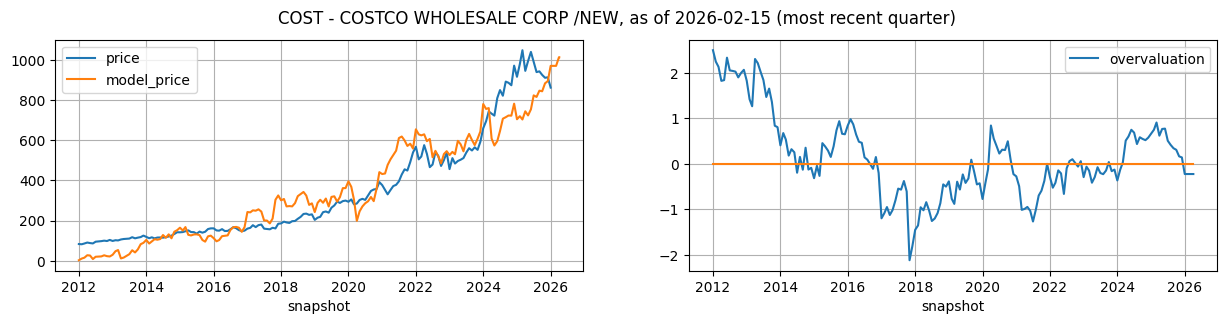

COST model_price = 19.070710 * (1.112172 * Assets - Liabilities + cashmul * NetCashOperating_ttm) -211.439195


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,price,asmul,cashmul,model,hype,bias,model_price,overvaluation
snapshot,cik,,,,,,,,,,,,,
2025-12-01,0000909832,2025-08-31,COST,77.099,47.935,13.335,913.59,1.112172,1.514211,58.004334,19.07071,-211.439195,894.744667,0.140854
2026-01-01,0000909832,2025-11-23,COST,82.790,52.487,14.763,862.34,1.112172,1.517291,61.989465,19.07071,-211.439195,970.743950,-0.224120
2026-02-01,0000909832,2025-11-23,COST,82.790,52.487,14.763,NaN,1.112172,1.517291,61.989465,19.07071,-211.439195,970.743950,-0.224120
2026-03-01,0000909832,2025-11-23,COST,82.790,52.487,14.763,NaN,1.112172,1.517291,61.989465,19.07071,-211.439195,970.743950,-0.224120
2026-04-01,0000909832,2026-02-15,COST,83.639,51.552,15.011,NaN,1.112172,1.517291,64.244987,19.07071,-211.439195,1013.758356,-0.224120
2026-04-04,0000909832,2026-02-15,COST,83.639,51.552,15.011,NaN,1.112172,1.517291,64.244987,19.07071,-211.439195,1013.758356,-0.224120


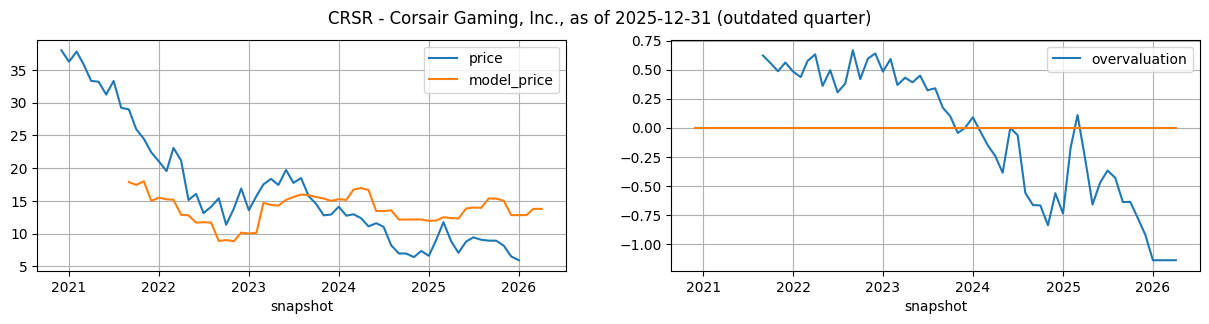

CRSR model_price = 20.187721 * (1.727590 * Assets - Liabilities + cashmul * NetCashOperating_ttm) -18.966847


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,price,asmul,cashmul,model,hype,bias,model_price,overvaluation
snapshot,cik,,,,,,,,,,,,,
2025-12-01,0001743759,2025-09-30,CRSR,1.198499,0.598269,0.067507,6.52,1.72759,1.514211,1.574465,20.187721,-18.966847,12.818018,-0.920891
2026-01-01,0001743759,2025-09-30,CRSR,1.198499,0.598269,0.067507,5.94,1.72759,1.517291,1.574673,20.187721,-18.966847,12.822216,-1.141152
2026-02-01,0001743759,2025-09-30,CRSR,1.198499,0.598269,0.067507,NaN,1.72759,1.517291,1.574673,20.187721,-18.966847,12.822216,-1.141152
2026-03-01,0001743759,2025-12-31,CRSR,1.253784,0.620227,0.050121,NaN,1.72759,1.517291,1.621845,20.187721,-18.966847,13.774514,-1.141152
2026-04-01,0001743759,2025-12-31,CRSR,1.253784,0.620227,0.050121,NaN,1.72759,1.517291,1.621845,20.187721,-18.966847,13.774514,-1.141152
2026-04-04,0001743759,2025-12-31,CRSR,1.253784,0.620227,0.050121,NaN,1.72759,1.517291,1.621845,20.187721,-18.966847,13.774514,-1.141152


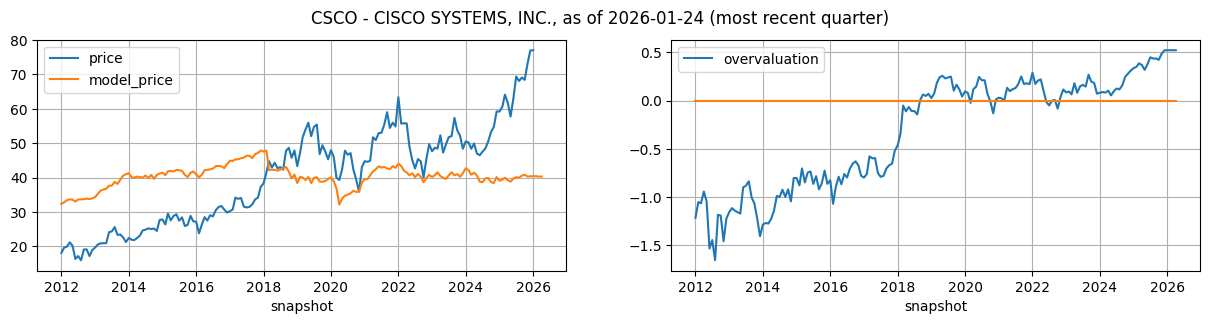

CSCO model_price = 0.315272 * (0.760969 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +28.152472


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,price,asmul,cashmul,model,hype,bias,model_price,overvaluation
snapshot,cik,,,,,,,,,,,,,
2025-12-01,0000858877,2025-10-25,CSCO,121.102,74.229,13.744,76.94,0.760969,1.514211,38.737231,0.315272,28.152472,40.365219,0.522964
2026-01-01,0000858877,2025-10-25,CSCO,121.102,74.229,13.744,77.03,0.760969,1.517291,38.779562,0.315272,28.152472,40.378564,0.523568
2026-02-01,0000858877,2025-10-25,CSCO,121.102,74.229,13.744,NaN,0.760969,1.517291,38.779562,0.315272,28.152472,40.378564,0.523568
2026-03-01,0000858877,2026-01-24,CSCO,123.371,75.648,13.325,NaN,0.760969,1.517291,38.451456,0.315272,28.152472,40.275122,0.523568
2026-04-01,0000858877,2026-01-24,CSCO,123.371,75.648,13.325,NaN,0.760969,1.517291,38.451456,0.315272,28.152472,40.275122,0.523568
2026-04-04,0000858877,2026-01-24,CSCO,123.371,75.648,13.325,NaN,0.760969,1.517291,38.451456,0.315272,28.152472,40.275122,0.523568


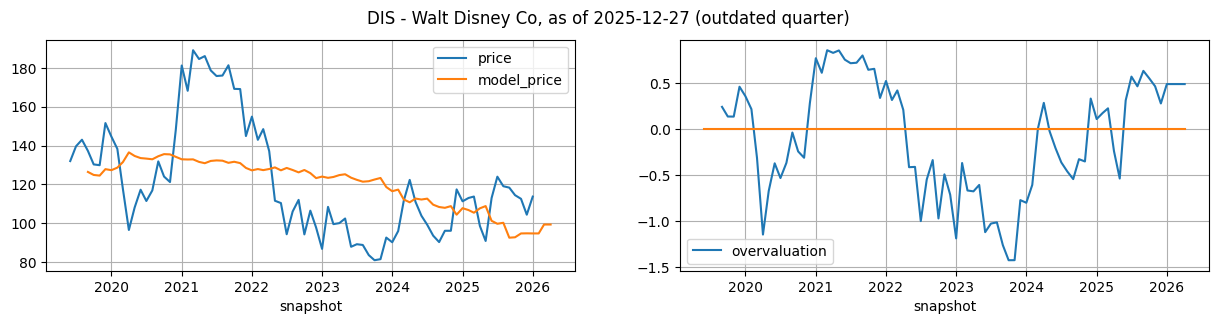

DIS model_price = -0.864946 * (0.964527 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +207.552353


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,price,asmul,cashmul,model,hype,bias,model_price,overvaluation
snapshot,cik,,,,,,,,,,,,,
2025-12-01,0001744489,2025-09-27,DIS,197.514,87.645,18.101,104.47,0.964527,1.514211,130.271367,-0.864946,207.552353,94.874617,0.276152
2026-01-01,0001744489,2025-09-27,DIS,197.514,87.645,18.101,113.77,0.964527,1.517291,130.327116,-0.864946,207.552353,94.826397,0.486258
2026-02-01,0001744489,2025-09-27,DIS,197.514,87.645,18.101,NaN,0.964527,1.517291,130.327116,-0.864946,207.552353,94.826397,0.486258
2026-03-01,0001744489,2025-12-27,DIS,202.089,93.613,15.631,NaN,0.964527,1.517291,125.024120,-0.864946,207.552353,99.413204,0.486258
2026-04-01,0001744489,2025-12-27,DIS,202.089,93.613,15.631,NaN,0.964527,1.517291,125.024120,-0.864946,207.552353,99.413204,0.486258
2026-04-04,0001744489,2025-12-27,DIS,202.089,93.613,15.631,NaN,0.964527,1.517291,125.024120,-0.864946,207.552353,99.413204,0.486258


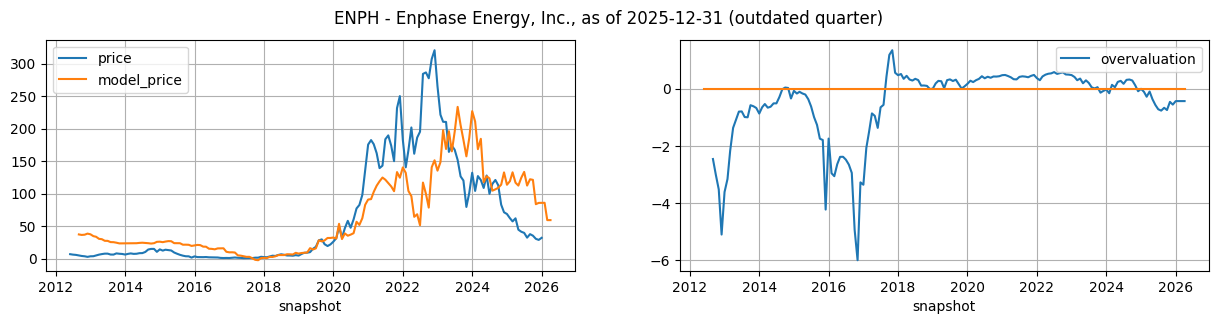

ENPH model_price = 179.253792 * (0.688715 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +23.146907


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,price,asmul,cashmul,model,hype,bias,model_price,overvaluation
snapshot,cik,,,,,,,,,,,,,
2025-12-01,0001463101,2025-09-30,ENPH,3.320488,2.325466,0.256253,28.85,0.688715,1.514211,0.349424,179.253792,23.146907,85.782402,-0.559837
2026-01-01,0001463101,2025-09-30,ENPH,3.320488,2.325466,0.256253,32.05,0.688715,1.517291,0.350213,179.253792,23.146907,85.923874,-0.437251
2026-02-01,0001463101,2025-09-30,ENPH,3.320488,2.325466,0.256253,NaN,0.688715,1.517291,0.350213,179.253792,23.146907,85.923874,-0.437251
2026-03-01,0001463101,2025-12-31,ENPH,3.509792,2.422769,0.136540,NaN,0.688715,1.517291,0.201647,179.253792,23.146907,59.292853,-0.437251
2026-04-01,0001463101,2025-12-31,ENPH,3.509792,2.422769,0.136540,NaN,0.688715,1.517291,0.201647,179.253792,23.146907,59.292853,-0.437251
2026-04-04,0001463101,2025-12-31,ENPH,3.509792,2.422769,0.136540,NaN,0.688715,1.517291,0.201647,179.253792,23.146907,59.292853,-0.437251


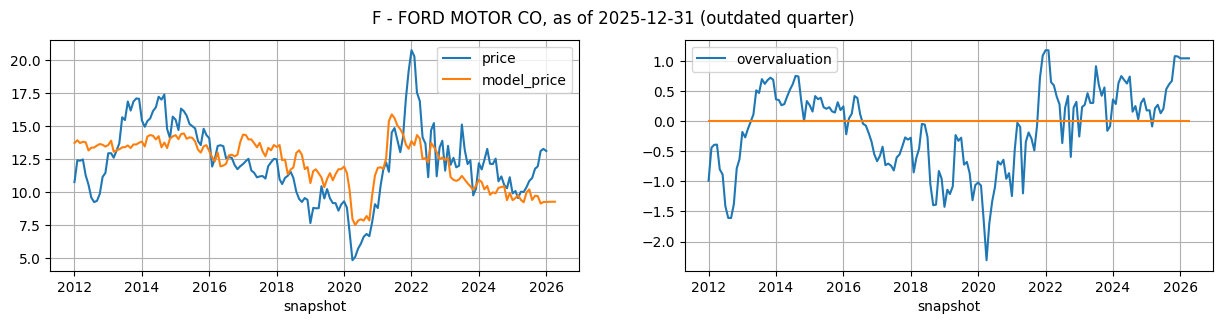

F model_price = 0.132849 * (0.133954 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +33.473171


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,price,asmul,cashmul,model,hype,bias,model_price,overvaluation
snapshot,cik,,,,,,,,,,,,,
2025-12-01,0000037996,2025-09-30,F,300.99,253.598,20.426,13.28,0.133954,1.514211,-182.350051,0.132849,33.473171,9.248107,1.076064
2026-01-01,0000037996,2025-09-30,F,300.99,253.598,20.426,13.12,0.133954,1.517291,-182.287141,0.132849,33.473171,9.256464,1.043508
2026-02-01,0000037996,2025-09-30,F,300.99,253.598,20.426,NaN,0.133954,1.517291,-182.287141,0.132849,33.473171,9.256464,1.043508
2026-03-01,0000037996,2025-12-31,F,289.16,253.208,21.282,NaN,0.133954,1.517291,-182.183010,0.132849,33.473171,9.270298,1.043508
2026-04-01,0000037996,2025-12-31,F,289.16,253.208,21.282,NaN,0.133954,1.517291,-182.183010,0.132849,33.473171,9.270298,1.043508
2026-04-04,0000037996,2025-12-31,F,289.16,253.208,21.282,NaN,0.133954,1.517291,-182.183010,0.132849,33.473171,9.270298,1.043508


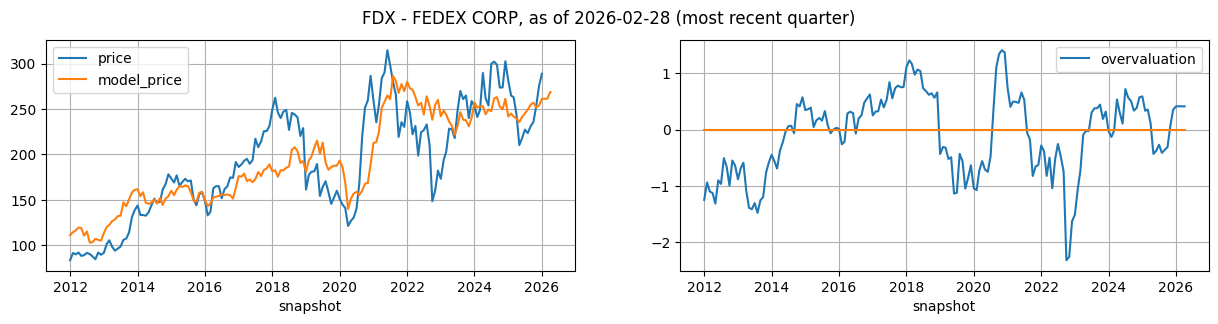

FDX model_price = 5.780408 * (0.937878 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +58.775253


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,price,asmul,cashmul,model,hype,bias,model_price,overvaluation
snapshot,cik,,,,,,,,,,,,,
2025-12-01,0001048911,2025-08-31,FDX,88.416,60.645,7.565,275.68,0.937878,1.514211,33.733428,5.780408,58.775253,253.768246,0.351002
2026-01-01,0001048911,2025-11-30,FDX,89.181,61.041,8.198,288.86,0.937878,1.517291,35.038649,5.780408,58.775253,261.312957,0.412955
2026-02-01,0001048911,2025-11-30,FDX,89.181,61.041,8.198,NaN,0.937878,1.517291,35.038649,5.780408,58.775253,261.312957,0.412955
2026-03-01,0001048911,2025-11-30,FDX,89.181,61.041,8.198,NaN,0.937878,1.517291,35.038649,5.780408,58.775253,261.312957,0.412955
2026-04-01,0001048911,2026-02-28,FDX,94.733,64.929,8.179,NaN,0.937878,1.517291,36.328919,5.780408,58.775253,268.771246,0.412955
2026-04-04,0001048911,2026-02-28,FDX,94.733,64.929,8.179,NaN,0.937878,1.517291,36.328919,5.780408,58.775253,268.771246,0.412955


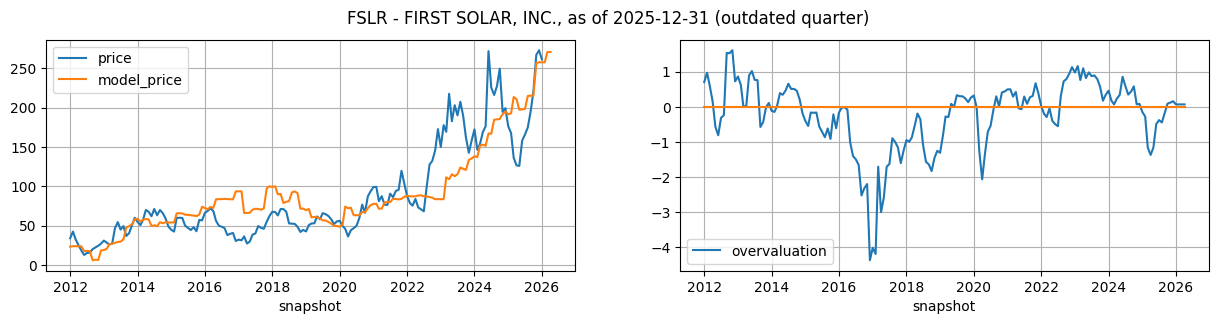

FSLR model_price = 13.053361 * (2.316665 * Assets - Liabilities + cashmul * NetCashOperating_ttm) -123.615940


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,price,asmul,cashmul,model,hype,bias,model_price,overvaluation
snapshot,cik,,,,,,,,,,,,,
2025-12-01,0001274494,2025-09-30,FSLR,13.459309,4.443997,1.626208,272.92,2.316665,1.514211,29.199134,13.053361,-123.61594,257.530887,0.157119
2026-01-01,0001274494,2025-09-30,FSLR,13.459309,4.443997,1.626208,261.23,2.316665,1.517291,29.204143,13.053361,-123.61594,257.596266,0.067106
2026-02-01,0001274494,2025-09-30,FSLR,13.459309,4.443997,1.626208,NaN,2.316665,1.517291,29.204143,13.053361,-123.61594,257.596266,0.067106
2026-03-01,0001274494,2025-12-31,FSLR,13.321310,3.783317,2.057105,NaN,2.316665,1.517291,30.198921,13.053361,-123.61594,270.581470,0.067106
2026-04-01,0001274494,2025-12-31,FSLR,13.321310,3.783317,2.057105,NaN,2.316665,1.517291,30.198921,13.053361,-123.61594,270.581470,0.067106
2026-04-04,0001274494,2025-12-31,FSLR,13.321310,3.783317,2.057105,NaN,2.316665,1.517291,30.198921,13.053361,-123.61594,270.581470,0.067106


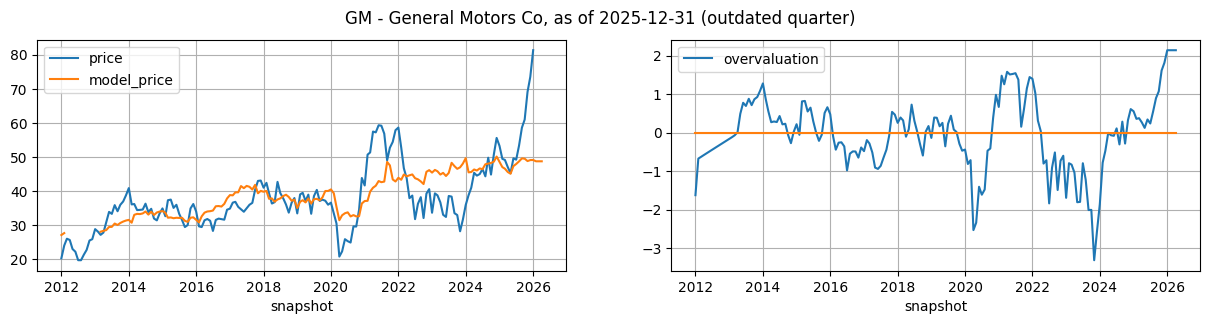

GM model_price = 0.277314 * (1.019663 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +18.945739


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,price,asmul,cashmul,model,hype,bias,model_price,overvaluation
snapshot,cik,,,,,,,,,,,,,
2025-12-01,0001467858,2025-09-30,GM,288.168,221.794,24.212,73.52,1.019663,1.514211,108.702316,0.277314,18.945739,49.090397,1.813980
2026-01-01,0001467858,2025-09-30,GM,288.168,221.794,24.212,81.32,1.019663,1.517291,108.776886,0.277314,18.945739,49.111077,2.141709
2026-02-01,0001467858,2025-12-31,GM,281.284,220.165,26.867,NaN,1.019663,1.517291,107.414933,0.277314,18.945739,48.733388,2.141709
2026-03-01,0001467858,2025-12-31,GM,281.284,220.165,26.867,NaN,1.019663,1.517291,107.414933,0.277314,18.945739,48.733388,2.141709
2026-04-01,0001467858,2025-12-31,GM,281.284,220.165,26.867,NaN,1.019663,1.517291,107.414933,0.277314,18.945739,48.733388,2.141709
2026-04-04,0001467858,2025-12-31,GM,281.284,220.165,26.867,NaN,1.019663,1.517291,107.414933,0.277314,18.945739,48.733388,2.141709


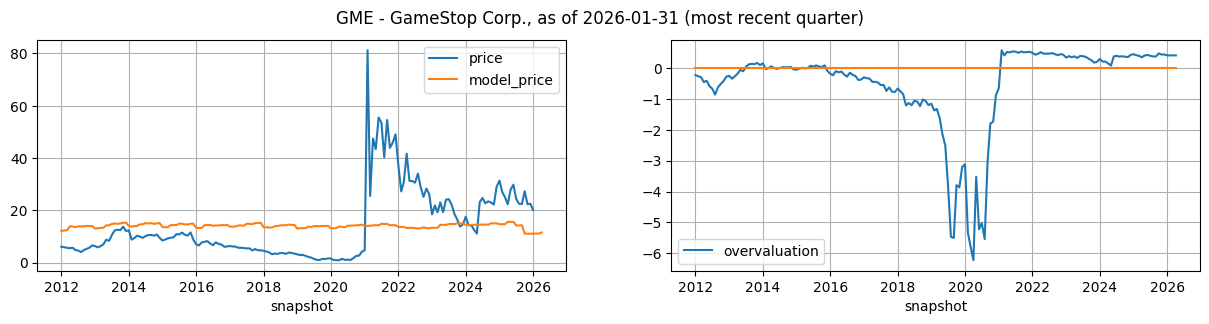

GME model_price = 1.237978 * (0.000232 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +16.486310


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,price,asmul,cashmul,model,hype,bias,model_price,overvaluation
snapshot,cik,,,,,,,,,,,,,
2025-12-01,0001326380,2025-08-02,GME,10.3411,5.1647,0.4968,22.53,0.000232,1.514211,-4.410046,1.237978,16.48631,11.026771,0.440257
2026-01-01,0001326380,2025-11-01,GME,10.5507,5.2477,0.5835,20.08,0.000232,1.517291,-4.359918,1.237978,16.48631,11.088828,0.412693
2026-02-01,0001326380,2025-11-01,GME,10.5507,5.2477,0.5835,NaN,0.000232,1.517291,-4.359918,1.237978,16.48631,11.088828,0.412693
2026-03-01,0001326380,2025-11-01,GME,10.5507,5.2477,0.5835,NaN,0.000232,1.517291,-4.359918,1.237978,16.48631,11.088828,0.412693
2026-04-01,0001326380,2026-01-31,GME,10.3884,4.9440,0.6148,NaN,0.000232,1.517291,-4.008764,1.237978,16.48631,11.523549,0.412693
2026-04-04,0001326380,2026-01-31,GME,10.3884,4.9440,0.6148,NaN,0.000232,1.517291,-4.008764,1.237978,16.48631,11.523549,0.412693


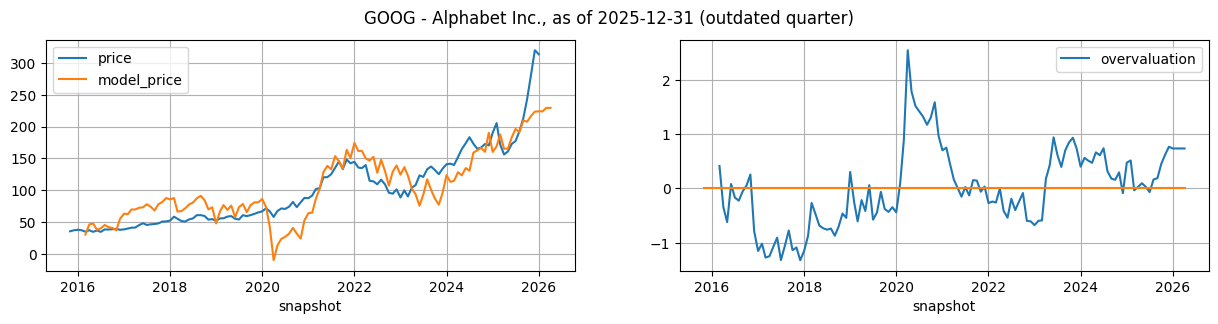

GOOG model_price = 1.027176 * (0.264136 * Assets - Liabilities + cashmul * NetCashOperating_ttm) -3.817139


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,price,asmul,cashmul,model,hype,bias,model_price,overvaluation
snapshot,cik,,,,,,,,,,,,,
2025-12-01,0001652044,2025-09-30,GOOG,536.469,149.602,151.424,320.12,0.264136,1.514211,221.386870,1.027176,-3.817139,223.586223,0.769682
2026-01-01,0001652044,2025-09-30,GOOG,536.469,149.602,151.424,313.80,0.264136,1.517291,221.853239,1.027176,-3.817139,224.065267,0.737770
2026-02-01,0001652044,2025-09-30,GOOG,536.469,149.602,151.424,NaN,0.264136,1.517291,221.853239,1.027176,-3.817139,224.065267,0.737770
2026-03-01,0001652044,2025-12-31,GOOG,595.281,180.016,164.713,NaN,0.264136,1.517291,227.136907,1.027176,-3.817139,229.492526,0.737770
2026-04-01,0001652044,2025-12-31,GOOG,595.281,180.016,164.713,NaN,0.264136,1.517291,227.136907,1.027176,-3.817139,229.492526,0.737770
2026-04-04,0001652044,2025-12-31,GOOG,595.281,180.016,164.713,NaN,0.264136,1.517291,227.136907,1.027176,-3.817139,229.492526,0.737770


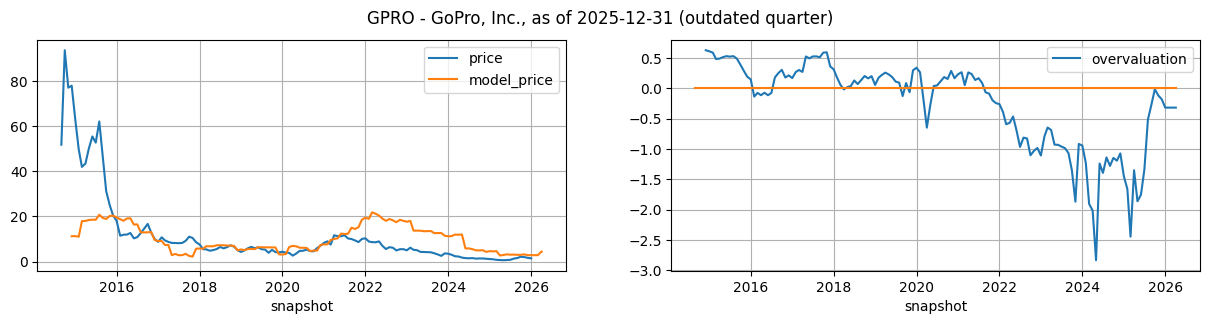

GPRO model_price = 20.336774 * (0.819042 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +5.054358


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,price,asmul,cashmul,model,hype,bias,model_price,overvaluation
snapshot,cik,,,,,,,,,,,,,
2025-12-01,0001500435,2025-09-30,GPRO,0.538608,0.458114,-0.061371,1.63,0.819042,1.514211,-0.109900,20.336774,5.054358,2.819349,-0.183073
2026-01-01,0001500435,2025-09-30,GPRO,0.538608,0.458114,-0.061371,1.41,0.819042,1.517291,-0.110089,20.336774,5.054358,2.815505,-0.319271
2026-02-01,0001500435,2025-09-30,GPRO,0.538608,0.458114,-0.061371,NaN,0.819042,1.517291,-0.110089,20.336774,5.054358,2.815505,-0.319271
2026-03-01,0001500435,2025-09-30,GPRO,0.538608,0.458114,-0.061371,NaN,0.819042,1.517291,-0.110089,20.336774,5.054358,2.815505,-0.319271
2026-04-01,0001500435,2025-12-31,GPRO,0.427983,0.351433,-0.020669,NaN,0.819042,1.517291,-0.032258,20.336774,5.054358,4.398341,-0.319271
2026-04-04,0001500435,2025-12-31,GPRO,0.427983,0.351433,-0.020669,NaN,0.819042,1.517291,-0.032258,20.336774,5.054358,4.398341,-0.319271


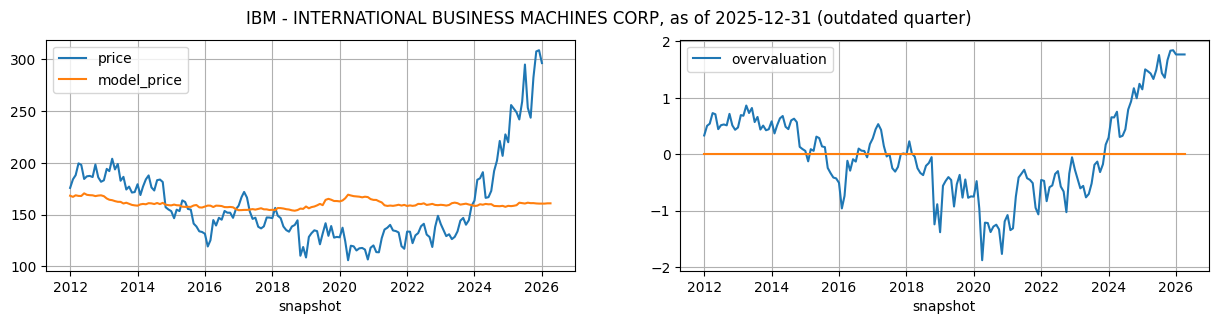

IBM model_price = -0.250402 * (0.033844 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +137.362683


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,price,asmul,cashmul,model,hype,bias,model_price,overvaluation
snapshot,cik,,,,,,,,,,,,,
2025-12-01,0000051143,2025-09-30,IBM,146.312,118.407,13.483,308.58,0.033844,1.514211,-93.039047,-0.250402,137.362683,160.659849,1.842793
2026-01-01,0000051143,2025-09-30,IBM,146.312,118.407,13.483,296.21,0.033844,1.517291,-92.997521,-0.250402,137.362683,160.649450,1.767661
2026-02-01,0000051143,2025-09-30,IBM,146.312,118.407,13.483,NaN,0.033844,1.517291,-92.997521,-0.250402,137.362683,160.649450,1.767661
2026-03-01,0000051143,2025-12-31,IBM,151.880,119.232,13.193,NaN,0.033844,1.517291,-94.074089,-0.250402,137.362683,160.919025,1.767661
2026-04-01,0000051143,2025-12-31,IBM,151.880,119.232,13.193,NaN,0.033844,1.517291,-94.074089,-0.250402,137.362683,160.919025,1.767661
2026-04-04,0000051143,2025-12-31,IBM,151.880,119.232,13.193,NaN,0.033844,1.517291,-94.074089,-0.250402,137.362683,160.919025,1.767661


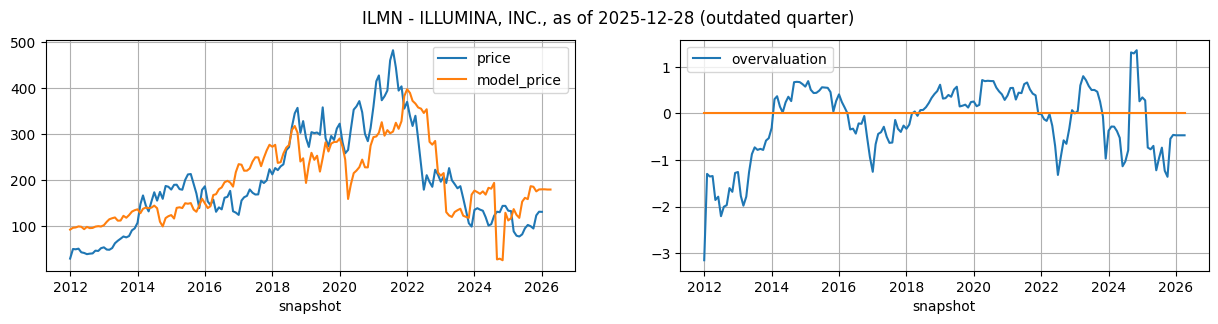

ILMN model_price = 86.270473 * (0.395429 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +150.019114


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,price,asmul,cashmul,model,hype,bias,model_price,overvaluation
snapshot,cik,,,,,,,,,,,,,
2025-12-01,0001110803,2025-09-28,ILMN,6.177,3.796,1.122,131.45,0.395429,1.514211,0.345509,86.270473,150.019114,179.826320,-0.461802
2026-01-01,0001110803,2025-09-28,ILMN,6.177,3.796,1.122,131.16,0.395429,1.517291,0.348964,86.270473,150.019114,180.124440,-0.469917
2026-02-01,0001110803,2025-09-28,ILMN,6.177,3.796,1.122,NaN,0.395429,1.517291,0.348964,86.270473,150.019114,180.124440,-0.469917
2026-03-01,0001110803,2025-12-28,ILMN,6.644,3.921,1.079,NaN,0.395429,1.517291,0.343386,86.270473,150.019114,179.643204,-0.469917
2026-04-01,0001110803,2025-12-28,ILMN,6.644,3.921,1.079,NaN,0.395429,1.517291,0.343386,86.270473,150.019114,179.643204,-0.469917
2026-04-04,0001110803,2025-12-28,ILMN,6.644,3.921,1.079,NaN,0.395429,1.517291,0.343386,86.270473,150.019114,179.643204,-0.469917


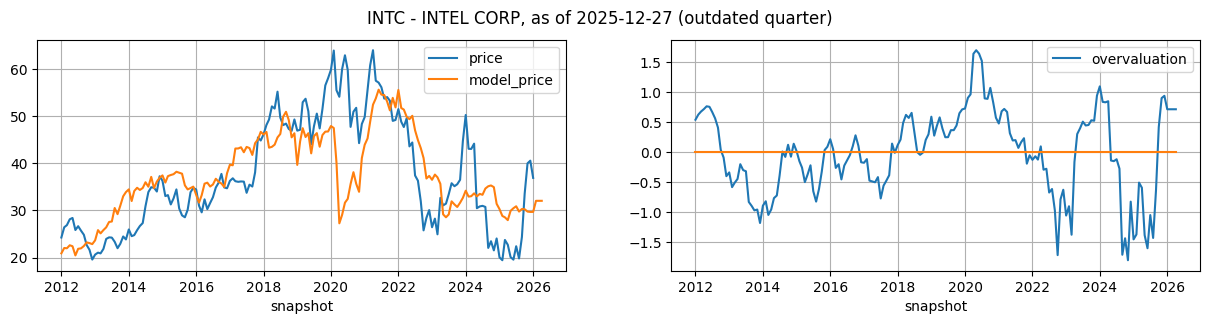

INTC model_price = 0.413574 * (0.431532 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +28.398036


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,price,asmul,cashmul,model,hype,bias,model_price,overvaluation
snapshot,cik,,,,,,,,,,,,,
2025-12-01,0000050863,2025-09-27,INTC,204.514,98.138,8.574,40.56,0.431532,1.514211,3.099173,0.413574,28.398036,29.679774,0.940182
2026-01-01,0000050863,2025-09-27,INTC,204.514,98.138,8.574,36.90,0.431532,1.517291,3.125580,0.413574,28.398036,29.690695,0.715864
2026-02-01,0000050863,2025-12-27,INTC,211.429,97.148,9.697,NaN,0.431532,1.517291,8.803541,0.413574,28.398036,32.038954,0.715864
2026-03-01,0000050863,2025-12-27,INTC,211.429,97.148,9.697,NaN,0.431532,1.517291,8.803541,0.413574,28.398036,32.038954,0.715864
2026-04-01,0000050863,2025-12-27,INTC,211.429,97.148,9.697,NaN,0.431532,1.517291,8.803541,0.413574,28.398036,32.038954,0.715864
2026-04-04,0000050863,2025-12-27,INTC,211.429,97.148,9.697,NaN,0.431532,1.517291,8.803541,0.413574,28.398036,32.038954,0.715864


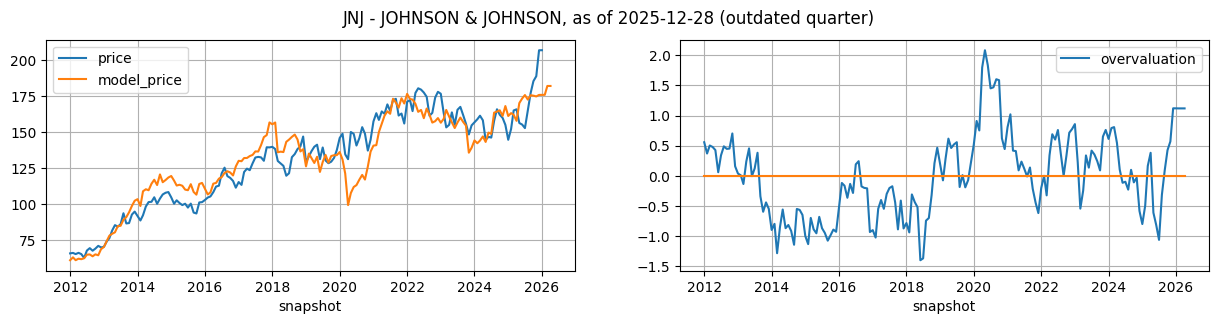

JNJ model_price = 0.991686 * (1.540236 * Assets - Liabilities + cashmul * NetCashOperating_ttm) -42.423208


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,price,asmul,cashmul,model,hype,bias,model_price,overvaluation
snapshot,cik,,,,,,,,,,,,,
2025-12-01,0000200406,2025-09-28,JNJ,192.816,113.539,24.204,206.92,1.540236,1.514211,220.093151,0.991686,-42.423208,175.840054,1.120876
2026-01-01,0000200406,2025-09-28,JNJ,192.816,113.539,24.204,206.95,1.540236,1.517291,220.167697,0.991686,-42.423208,175.913980,1.119177
2026-02-01,0000200406,2025-09-28,JNJ,192.816,113.539,24.204,NaN,1.540236,1.517291,220.167697,0.991686,-42.423208,175.913980,1.119177
2026-03-01,0000200406,2025-12-28,JNJ,199.210,117.666,24.530,NaN,1.540236,1.517291,226.383604,0.991686,-42.423208,182.078207,1.119177
2026-04-01,0000200406,2025-12-28,JNJ,199.210,117.666,24.530,NaN,1.540236,1.517291,226.383604,0.991686,-42.423208,182.078207,1.119177
2026-04-04,0000200406,2025-12-28,JNJ,199.210,117.666,24.530,NaN,1.540236,1.517291,226.383604,0.991686,-42.423208,182.078207,1.119177


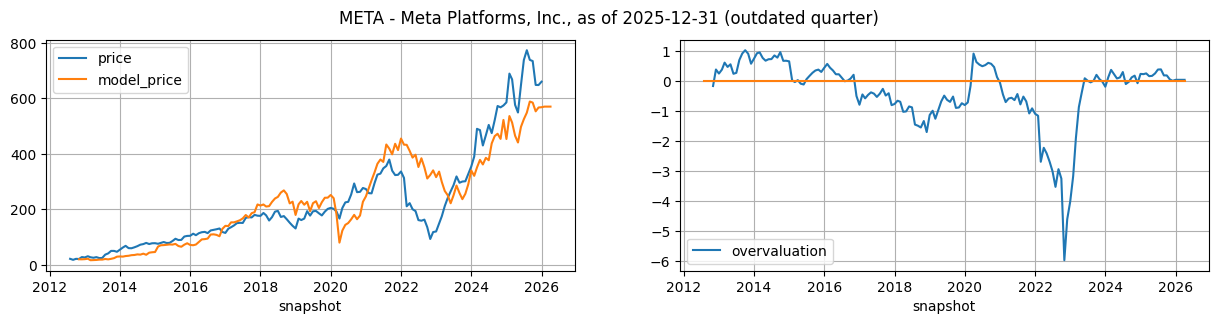

META model_price = 2.986874 * (0.438312 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +10.624073


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,price,asmul,cashmul,model,hype,bias,model_price,overvaluation
snapshot,cik,,,,,,,,,,,,,
2025-12-01,0001326801,2025-09-30,META,303.844,109.778,107.574,647.95,0.438312,1.514211,186.290197,2.986874,10.624073,567.049354,-0.001397
2026-01-01,0001326801,2025-09-30,META,303.844,109.778,107.574,660.09,0.438312,1.517291,186.621513,2.986874,10.624073,568.038954,0.032139
2026-02-01,0001326801,2025-12-31,META,366.021,148.778,115.800,NaN,0.438312,1.517291,187.355673,2.986874,10.624073,570.231794,0.032139
2026-03-01,0001326801,2025-12-31,META,366.021,148.778,115.800,NaN,0.438312,1.517291,187.355673,2.986874,10.624073,570.231794,0.032139
2026-04-01,0001326801,2025-12-31,META,366.021,148.778,115.800,NaN,0.438312,1.517291,187.355673,2.986874,10.624073,570.231794,0.032139
2026-04-04,0001326801,2025-12-31,META,366.021,148.778,115.800,NaN,0.438312,1.517291,187.355673,2.986874,10.624073,570.231794,0.032139


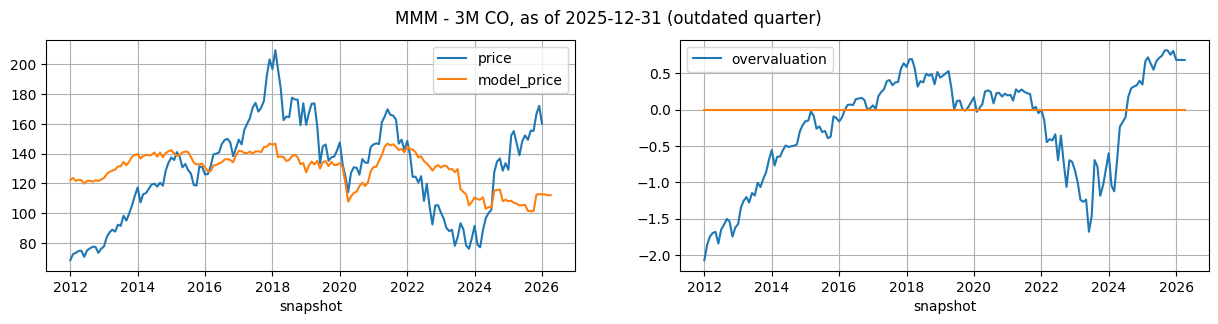

MMM model_price = 1.900856 * (0.484907 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +133.365585


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,price,asmul,cashmul,model,hype,bias,model_price,overvaluation
snapshot,cik,,,,,,,,,,,,,
2025-12-01,0000066740,2025-09-30,MMM,37.611,32.983,2.541,172.05,0.484907,1.514211,-10.897548,1.900856,133.365585,112.650917,0.807476
2026-01-01,0000066740,2025-09-30,MMM,37.611,32.983,2.541,160.10,0.484907,1.517291,-10.889722,1.900856,133.365585,112.665793,0.683120
2026-02-01,0000066740,2025-09-30,MMM,37.611,32.983,2.541,NaN,0.484907,1.517291,-10.889722,1.900856,133.365585,112.665793,0.683120
2026-03-01,0000066740,2025-12-31,MMM,37.733,33.031,2.306,NaN,0.484907,1.517291,-11.235127,1.900856,133.365585,112.009228,0.683120
2026-04-01,0000066740,2025-12-31,MMM,37.733,33.031,2.306,NaN,0.484907,1.517291,-11.235127,1.900856,133.365585,112.009228,0.683120
2026-04-04,0000066740,2025-12-31,MMM,37.733,33.031,2.306,NaN,0.484907,1.517291,-11.235127,1.900856,133.365585,112.009228,0.683120


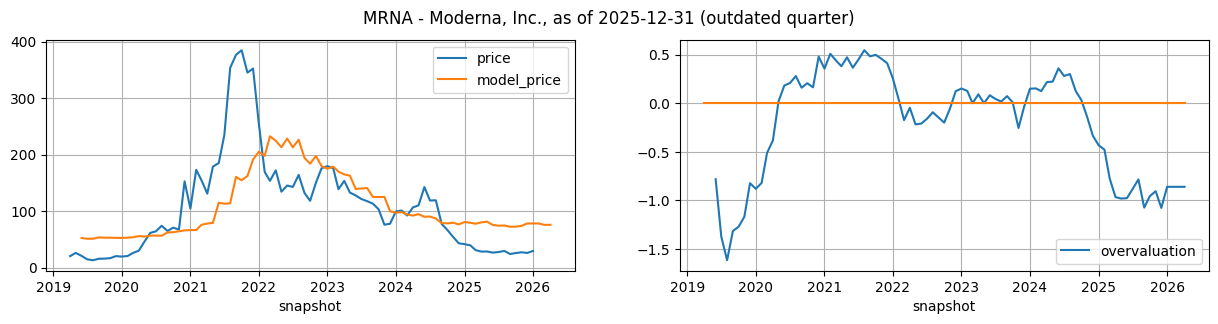

MRNA model_price = 4.624168 * (0.974637 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +50.300429


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,price,asmul,cashmul,model,hype,bias,model_price,overvaluation
snapshot,cik,,,,,,,,,,,,,
2025-12-01,0001682852,2025-09-30,MRNA,12.135,2.805,-1.978,25.98,0.974637,1.514211,6.027109,4.624168,50.300429,78.170796,-1.078659
2026-01-01,0001682852,2025-09-30,MRNA,12.135,2.805,-1.978,29.49,0.974637,1.517291,6.021017,4.624168,50.300429,78.142625,-0.861553
2026-02-01,0001682852,2025-09-30,MRNA,12.135,2.805,-1.978,NaN,0.974637,1.517291,6.021017,4.624168,50.300429,78.142625,-0.861553
2026-03-01,0001682852,2025-12-31,MRNA,12.338,3.688,-1.873,NaN,0.974637,1.517291,5.495184,4.624168,50.300429,75.711084,-0.861553
2026-04-01,0001682852,2025-12-31,MRNA,12.338,3.688,-1.873,NaN,0.974637,1.517291,5.495184,4.624168,50.300429,75.711084,-0.861553
2026-04-04,0001682852,2025-12-31,MRNA,12.338,3.688,-1.873,NaN,0.974637,1.517291,5.495184,4.624168,50.300429,75.711084,-0.861553


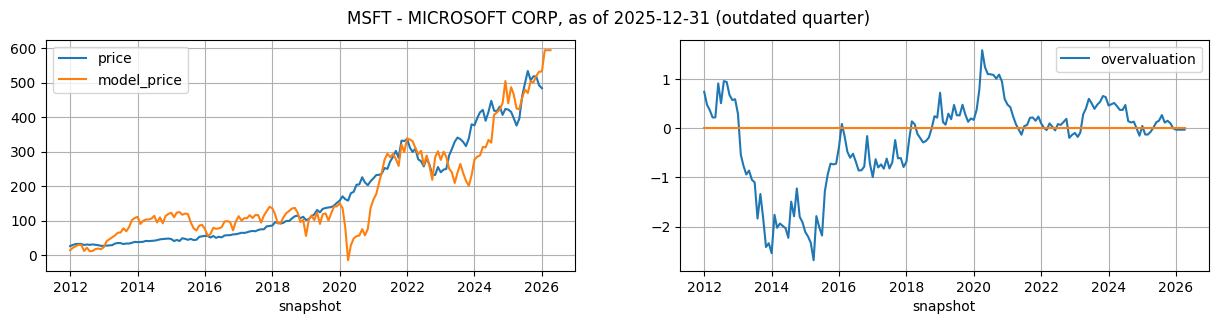

MSFT model_price = 1.891226 * (0.459509 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +73.975309


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,price,asmul,cashmul,model,hype,bias,model_price,overvaluation
snapshot,cik,,,,,,,,,,,,,
2025-12-01,0000789019,2025-09-30,MSFT,636.351,273.275,147.039,492.01,0.459509,1.514211,241.782008,1.891226,73.975309,531.239643,-0.005783
2026-01-01,0000789019,2025-09-30,MSFT,636.351,273.275,147.039,483.62,0.459509,1.517291,242.234872,1.891226,73.975309,532.096112,-0.033442
2026-02-01,0000789019,2025-12-31,MSFT,665.302,274.427,160.506,NaN,0.459509,1.517291,274.819470,1.891226,73.975309,593.720938,-0.033442
2026-03-01,0000789019,2025-12-31,MSFT,665.302,274.427,160.506,NaN,0.459509,1.517291,274.819470,1.891226,73.975309,593.720938,-0.033442
2026-04-01,0000789019,2025-12-31,MSFT,665.302,274.427,160.506,NaN,0.459509,1.517291,274.819470,1.891226,73.975309,593.720938,-0.033442
2026-04-04,0000789019,2025-12-31,MSFT,665.302,274.427,160.506,NaN,0.459509,1.517291,274.819470,1.891226,73.975309,593.720938,-0.033442


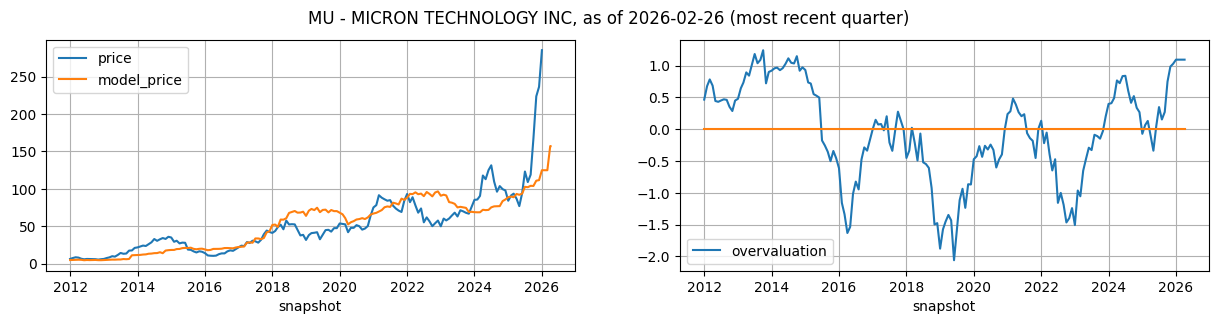

MU model_price = 0.919624 * (1.601162 * Assets - Liabilities + cashmul * NetCashOperating_ttm) -8.318713


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,price,asmul,cashmul,model,hype,bias,model_price,overvaluation
snapshot,cik,,,,,,,,,,,,,
2025-12-01,0000723125,2025-08-28,MU,82.798,28.633,17.525,236.48,1.601162,1.514211,130.476535,0.919624,-8.318713,111.670614,1.029973
2026-01-01,0000723125,2025-11-27,MU,85.971,27.165,22.692,285.41,1.601162,1.517291,144.918838,0.919624,-8.318713,124.952099,1.094909
2026-02-01,0000723125,2025-11-27,MU,85.971,27.165,22.692,NaN,1.601162,1.517291,144.918838,0.919624,-8.318713,124.952099,1.094909
2026-03-01,0000723125,2025-11-27,MU,85.971,27.165,22.692,NaN,1.601162,1.517291,144.918838,0.919624,-8.318713,124.952099,1.094909
2026-04-01,0000723125,2026-02-26,MU,101.509,29.050,30.653,NaN,1.601162,1.517291,179.991841,0.919624,-8.318713,157.206067,1.094909
2026-04-04,0000723125,2026-02-26,MU,101.509,29.050,30.653,NaN,1.601162,1.517291,179.991841,0.919624,-8.318713,157.206067,1.094909


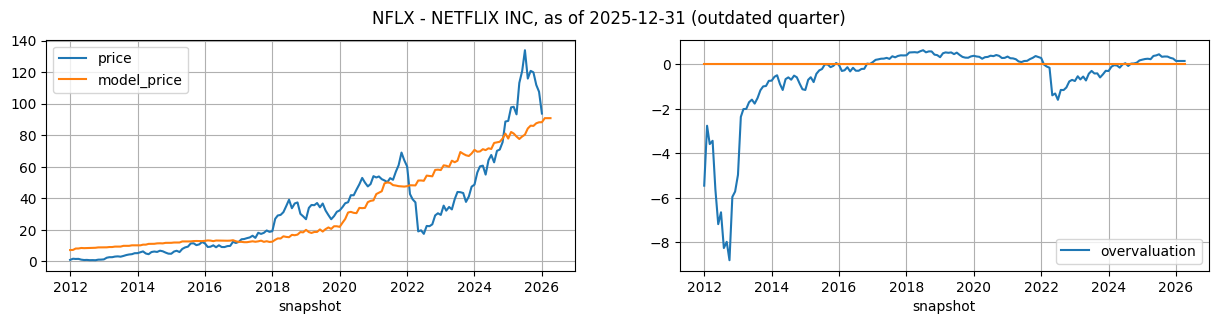

NFLX model_price = 1.512799 * (1.246437 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +6.554129


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,price,asmul,cashmul,model,hype,bias,model_price,overvaluation
snapshot,cik,,,,,,,,,,,,,
2025-12-01,0001065280,2025-09-30,NFLX,54.934835,28.980800,9.574525,107.58,1.246437,1.514211,53.989872,1.512799,6.554129,88.229977,0.258887
2026-01-01,0001065280,2025-09-30,NFLX,54.934835,28.980800,9.574525,93.76,1.246437,1.517291,54.019360,1.512799,6.554129,88.274588,0.151931
2026-02-01,0001065280,2025-12-31,NFLX,55.596993,28.981505,10.149273,NaN,1.246437,1.517291,55.716054,1.512799,6.554129,90.841344,0.151931
2026-03-01,0001065280,2025-12-31,NFLX,55.596993,28.981505,10.149273,NaN,1.246437,1.517291,55.716054,1.512799,6.554129,90.841344,0.151931
2026-04-01,0001065280,2025-12-31,NFLX,55.596993,28.981505,10.149273,NaN,1.246437,1.517291,55.716054,1.512799,6.554129,90.841344,0.151931
2026-04-04,0001065280,2025-12-31,NFLX,55.596993,28.981505,10.149273,NaN,1.246437,1.517291,55.716054,1.512799,6.554129,90.841344,0.151931


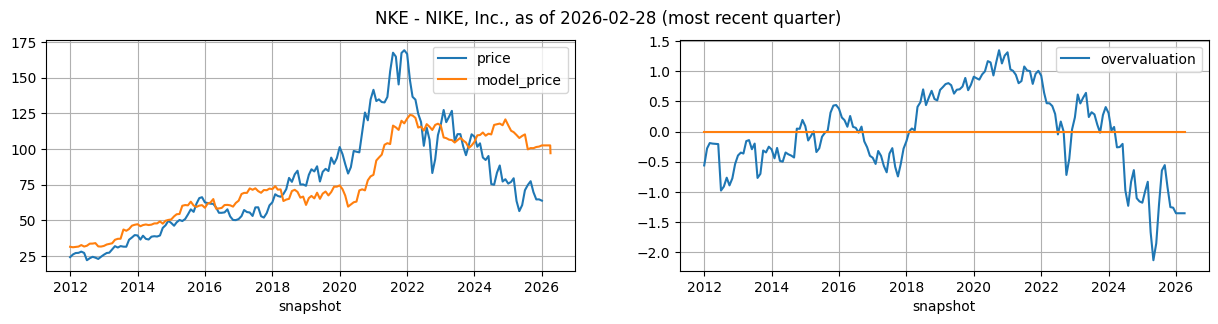

NKE model_price = 1.883162 * (2.169672 * Assets - Liabilities + cashmul * NetCashOperating_ttm) -16.011275


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,price,asmul,cashmul,model,hype,bias,model_price,overvaluation
snapshot,cik,,,,,,,,,,,,,
2025-12-01,0000320187,2025-08-31,NKE,37.334,23.866,3.526,64.63,2.169672,1.514211,62.475634,1.883162,-16.011275,101.640482,-1.263895
2026-01-01,0000320187,2025-11-30,NKE,37.787,23.702,3.056,63.71,2.169672,1.517291,62.920228,1.883162,-16.011275,102.477725,-1.356939
2026-02-01,0000320187,2025-11-30,NKE,37.787,23.702,3.056,NaN,2.169672,1.517291,62.920228,1.883162,-16.011275,102.477725,-1.356939
2026-03-01,0000320187,2025-11-30,NKE,37.787,23.702,3.056,NaN,2.169672,1.517291,62.920228,1.883162,-16.011275,102.477725,-1.356939
2026-04-01,0000320187,2025-11-30,NKE,37.787,23.702,3.056,NaN,2.169672,1.517291,62.920228,1.883162,-16.011275,102.477725,-1.356939
2026-04-04,0000320187,2026-02-28,NKE,37.064,22.974,1.694,NaN,2.169672,1.517291,60.013005,1.883162,-16.011275,97.002953,-1.356939


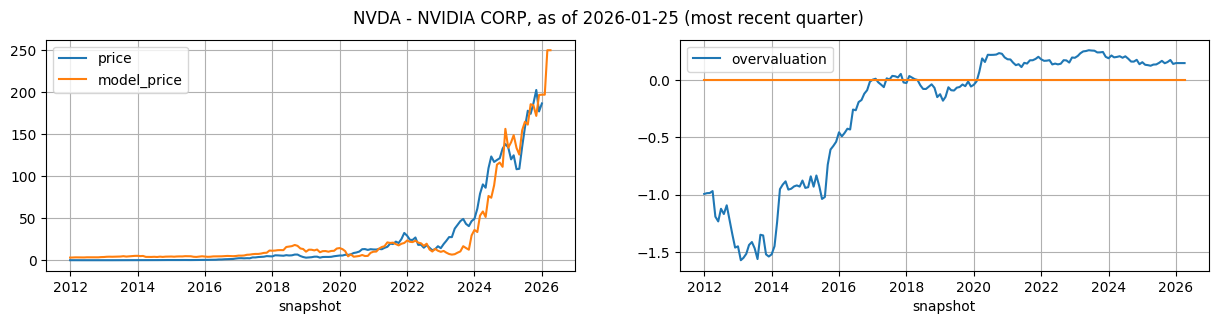

NVDA model_price = 1.368601 * (0.353796 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +4.041198


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,price,asmul,cashmul,model,hype,bias,model_price,overvaluation
snapshot,cik,,,,,,,,,,,,,
2025-12-01,0001045810,2025-10-26,NVDA,161.148,42.251,83.159,177.0,0.353796,1.514211,140.682834,1.368601,4.041198,196.579862,0.139985
2026-01-01,0001045810,2025-10-26,NVDA,161.148,42.251,83.159,186.5,0.353796,1.517291,140.938955,1.368601,4.041198,196.930389,0.147134
2026-02-01,0001045810,2025-10-26,NVDA,161.148,42.251,83.159,NaN,0.353796,1.517291,140.938955,1.368601,4.041198,196.930389,0.147134
2026-03-01,0001045810,2026-01-25,NVDA,206.803,49.510,102.718,NaN,0.353796,1.517291,179.509216,1.368601,4.041198,249.717687,0.147134
2026-04-01,0001045810,2026-01-25,NVDA,206.803,49.510,102.718,NaN,0.353796,1.517291,179.509216,1.368601,4.041198,249.717687,0.147134
2026-04-04,0001045810,2026-01-25,NVDA,206.803,49.510,102.718,NaN,0.353796,1.517291,179.509216,1.368601,4.041198,249.717687,0.147134


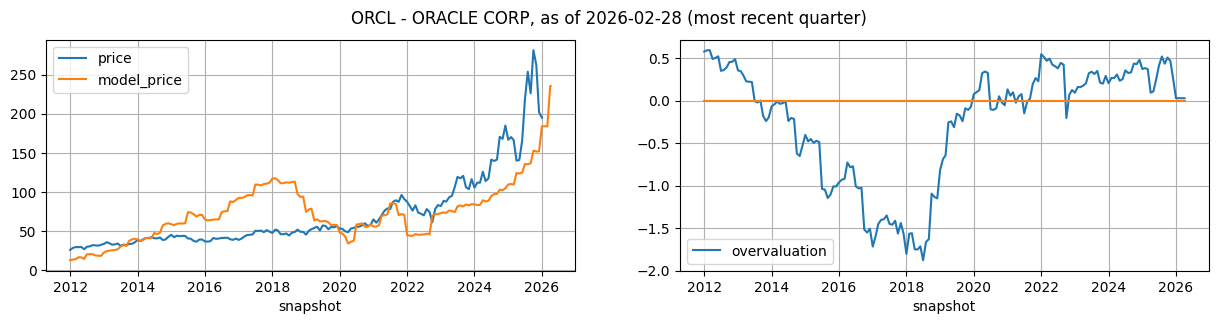

ORCL model_price = 0.488655 * (3.369785 * Assets - Liabilities + cashmul * NetCashOperating_ttm) -84.691149


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,price,asmul,cashmul,model,hype,bias,model_price,overvaluation
snapshot,cik,,,,,,,,,,,,,
2025-12-01,0001341439,2025-08-31,ORCL,180.449,156.295,21.534,201.95,3.369785,1.514211,484.386278,0.488655,-84.691149,152.006869,0.254558
2026-01-01,0001341439,2025-11-30,ORCL,204.984,175.033,22.296,194.91,3.369785,1.517291,549.548441,0.488655,-84.691149,183.848719,0.026818
2026-02-01,0001341439,2025-11-30,ORCL,204.984,175.033,22.296,NaN,3.369785,1.517291,549.548441,0.488655,-84.691149,183.848719,0.026818
2026-03-01,0001341439,2025-11-30,ORCL,204.984,175.033,22.296,NaN,3.369785,1.517291,549.548441,0.488655,-84.691149,183.848719,0.026818
2026-04-01,0001341439,2026-02-28,ORCL,245.240,206.745,23.514,NaN,3.369785,1.517291,655.338550,0.488655,-84.691149,235.543637,0.026818
2026-04-04,0001341439,2026-02-28,ORCL,245.240,206.745,23.514,NaN,3.369785,1.517291,655.338550,0.488655,-84.691149,235.543637,0.026818


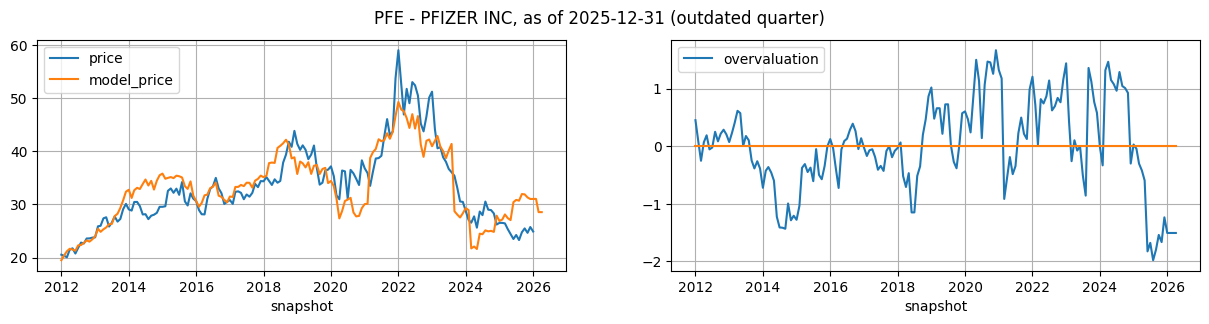

PFE model_price = 0.316550 * (0.054343 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +57.865064


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,price,asmul,cashmul,model,hype,bias,model_price,overvaluation
snapshot,cik,,,,,,,,,,,,,
2025-12-01,0000078003,2025-09-28,PFE,208.731,115.930,13.077,25.74,0.054343,1.514211,-84.785568,0.31655,57.865064,31.026198,-1.235907
2026-01-01,0000078003,2025-09-28,PFE,208.731,115.930,13.077,24.90,0.054343,1.517291,-84.745293,0.31655,57.865064,31.038947,-1.507089
2026-02-01,0000078003,2025-09-28,PFE,208.731,115.930,13.077,NaN,0.054343,1.517291,-84.745293,0.31655,57.865064,31.038947,-1.507089
2026-03-01,0000078003,2025-12-31,PFE,208.160,121.684,11.704,NaN,0.054343,1.517291,-92.613563,0.31655,57.865064,28.548247,-1.507089
2026-04-01,0000078003,2025-12-31,PFE,208.160,121.684,11.704,NaN,0.054343,1.517291,-92.613563,0.31655,57.865064,28.548247,-1.507089
2026-04-04,0000078003,2025-12-31,PFE,208.160,121.684,11.704,NaN,0.054343,1.517291,-92.613563,0.31655,57.865064,28.548247,-1.507089


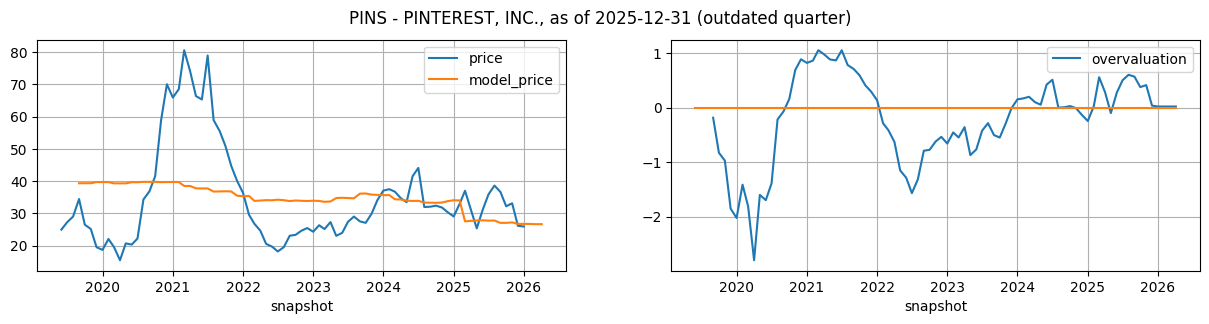

PINS model_price = -1.056589 * (3.359588 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +47.391732


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,price,asmul,cashmul,model,hype,bias,model_price,overvaluation
snapshot,cik,,,,,,,,,,,,,
2025-12-01,0001506293,2025-09-30,PINS,5.515410,0.690442,1.147046,26.12,3.359588,1.514211,19.575932,-1.056589,47.391732,26.708013,0.037284
2026-01-01,0001506293,2025-09-30,PINS,5.515410,0.690442,1.147046,25.89,3.359588,1.517291,19.579465,-1.056589,47.391732,26.704280,0.020627
2026-02-01,0001506293,2025-09-30,PINS,5.515410,0.690442,1.147046,NaN,3.359588,1.517291,19.579465,-1.056589,47.391732,26.704280,0.020627
2026-03-01,0001506293,2025-12-31,PINS,5.492132,0.746894,1.284264,NaN,3.359588,1.517291,19.653008,-1.056589,47.391732,26.626575,0.020627
2026-04-01,0001506293,2025-12-31,PINS,5.492132,0.746894,1.284264,NaN,3.359588,1.517291,19.653008,-1.056589,47.391732,26.626575,0.020627
2026-04-04,0001506293,2025-12-31,PINS,5.492132,0.746894,1.284264,NaN,3.359588,1.517291,19.653008,-1.056589,47.391732,26.626575,0.020627


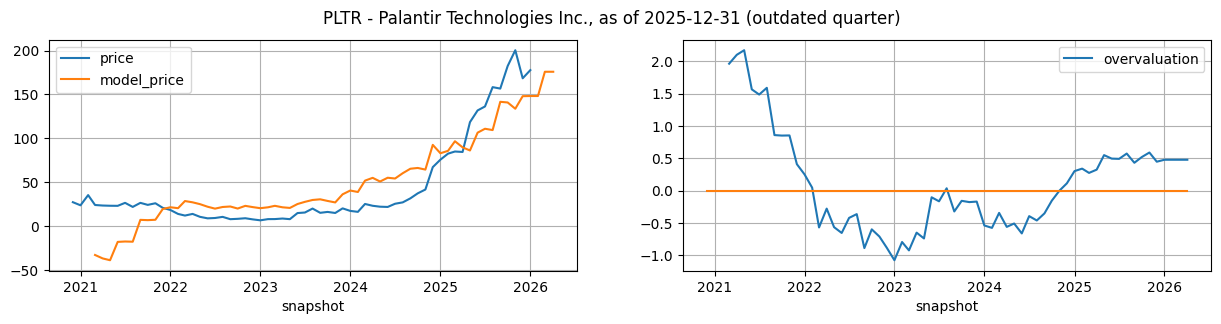

PLTR model_price = 34.660079 * (0.390569 * Assets - Liabilities + cashmul * NetCashOperating_ttm) -4.379640


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,price,asmul,cashmul,model,hype,bias,model_price,overvaluation
snapshot,cik,,,,,,,,,,,,,
2025-12-01,0001321655,2025-09-30,PLTR,8.113960,1.523503,1.817505,168.45,0.39057,1.514211,4.397648,34.660079,-4.37964,148.043197,0.446815
2026-01-01,0001321655,2025-09-30,PLTR,8.113960,1.523503,1.817505,177.75,0.39057,1.517291,4.403246,34.660079,-4.37964,148.237215,0.476824
2026-02-01,0001321655,2025-09-30,PLTR,8.113960,1.523503,1.817505,NaN,0.39057,1.517291,4.403246,34.660079,-4.37964,148.237215,0.476824
2026-03-01,0001321655,2025-12-31,PLTR,8.900392,1.513124,2.134473,NaN,0.39057,1.517291,5.201714,34.660079,-4.37964,175.912179,0.476824
2026-04-01,0001321655,2025-12-31,PLTR,8.900392,1.513124,2.134473,NaN,0.39057,1.517291,5.201714,34.660079,-4.37964,175.912179,0.476824
2026-04-04,0001321655,2025-12-31,PLTR,8.900392,1.513124,2.134473,NaN,0.39057,1.517291,5.201714,34.660079,-4.37964,175.912179,0.476824


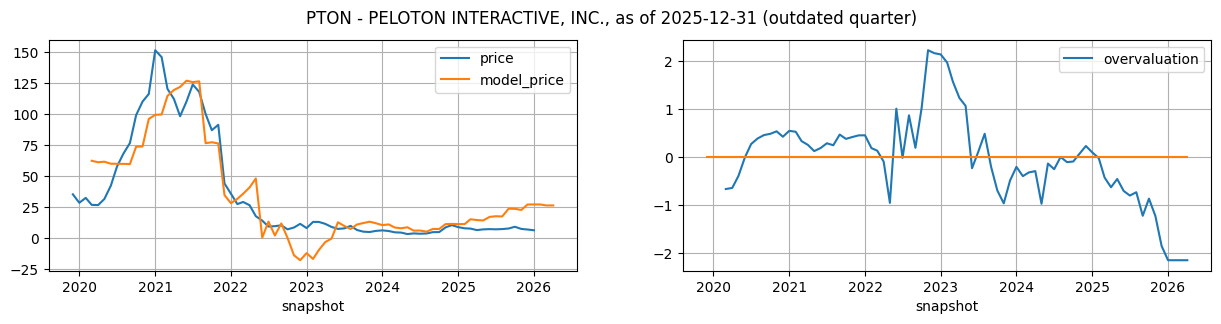

PTON model_price = 22.864901 * (1.482658 * Assets - Liabilities + cashmul * NetCashOperating_ttm) -2.582295


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,price,asmul,cashmul,model,hype,bias,model_price,overvaluation
snapshot,cik,,,,,,,,,,,,,
2025-12-01,0001639825,2025-09-30,PTON,2.1701,2.5171,0.3924,6.79,1.482658,1.514211,1.294593,22.864901,-2.582295,27.018448,-1.857656
2026-01-01,0001639825,2025-09-30,PTON,2.1701,2.5171,0.3924,6.16,1.482658,1.517291,1.295802,22.864901,-2.582295,27.046081,-2.155224
2026-02-01,0001639825,2025-09-30,PTON,2.1701,2.5171,0.3924,NaN,1.482658,1.517291,1.295802,22.864901,-2.582295,27.046081,-2.155224
2026-03-01,0001639825,2025-12-31,PTON,2.1646,2.4913,0.3576,NaN,1.482658,1.517291,1.260645,22.864901,-2.582295,26.242235,-2.155224
2026-04-01,0001639825,2025-12-31,PTON,2.1646,2.4913,0.3576,NaN,1.482658,1.517291,1.260645,22.864901,-2.582295,26.242235,-2.155224
2026-04-04,0001639825,2025-12-31,PTON,2.1646,2.4913,0.3576,NaN,1.482658,1.517291,1.260645,22.864901,-2.582295,26.242235,-2.155224


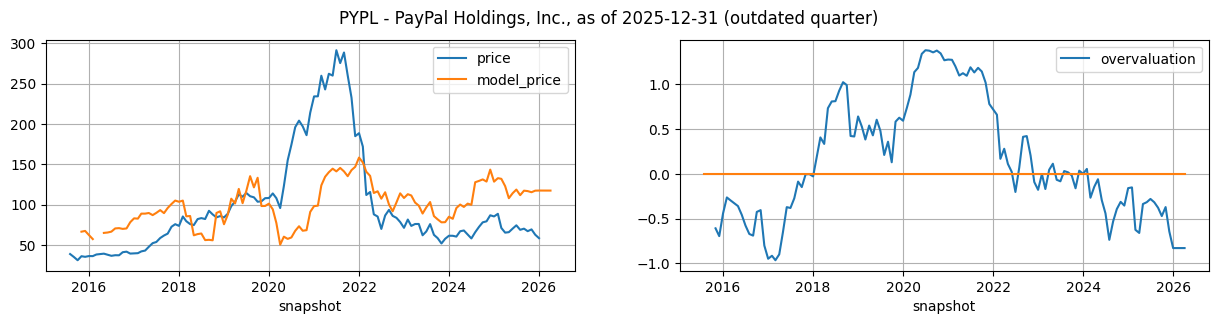

PYPL model_price = 7.008033 * (0.866183 * Assets - Liabilities + cashmul * NetCashOperating_ttm) -17.589961


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,price,asmul,cashmul,model,hype,bias,model_price,overvaluation
snapshot,cik,,,,,,,,,,,,,
2025-12-01,0001633917,2025-09-30,PYPL,79.801,59.603,6.426,62.69,0.866183,1.514211,19.249611,7.008033,-17.589961,117.311951,-0.644398
2026-01-01,0001633917,2025-09-30,PYPL,79.801,59.603,6.426,58.38,0.866183,1.517291,19.269403,7.008033,-17.589961,117.450649,-0.830261
2026-02-01,0001633917,2025-09-30,PYPL,79.801,59.603,6.426,NaN,0.866183,1.517291,19.269403,7.008033,-17.589961,117.450649,-0.830261
2026-03-01,0001633917,2025-12-31,PYPL,80.173,59.917,6.416,NaN,0.866183,1.517291,19.262450,7.008033,-17.589961,117.401924,-0.830261
2026-04-01,0001633917,2025-12-31,PYPL,80.173,59.917,6.416,NaN,0.866183,1.517291,19.262450,7.008033,-17.589961,117.401924,-0.830261
2026-04-04,0001633917,2025-12-31,PYPL,80.173,59.917,6.416,NaN,0.866183,1.517291,19.262450,7.008033,-17.589961,117.401924,-0.830261


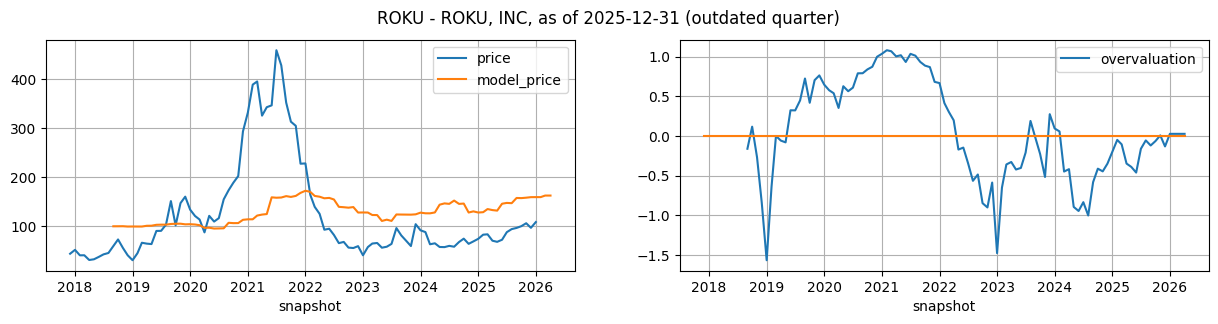

ROKU model_price = 55.350856 * (0.492528 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +99.408959


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,price,asmul,cashmul,model,hype,bias,model_price,overvaluation
snapshot,cik,,,,,,,,,,,,,
2025-12-01,0001428439,2025-09-30,ROKU,4.397285,1.772199,0.455360,96.79,0.492528,1.514211,1.083098,55.350856,99.408959,159.359348,-0.131937
2026-01-01,0001428439,2025-09-30,ROKU,4.397285,1.772199,0.455360,108.49,0.492528,1.517291,1.084500,55.350856,99.408959,159.436975,0.026681
2026-02-01,0001428439,2025-09-30,ROKU,4.397285,1.772199,0.455360,NaN,0.492528,1.517291,1.084500,55.350856,99.408959,159.436975,0.026681
2026-03-01,0001428439,2025-12-31,ROKU,4.433483,1.775538,0.483718,NaN,0.492528,1.517291,1.142017,55.350856,99.408959,162.620582,0.026681
2026-04-01,0001428439,2025-12-31,ROKU,4.433483,1.775538,0.483718,NaN,0.492528,1.517291,1.142017,55.350856,99.408959,162.620582,0.026681
2026-04-04,0001428439,2025-12-31,ROKU,4.433483,1.775538,0.483718,NaN,0.492528,1.517291,1.142017,55.350856,99.408959,162.620582,0.026681


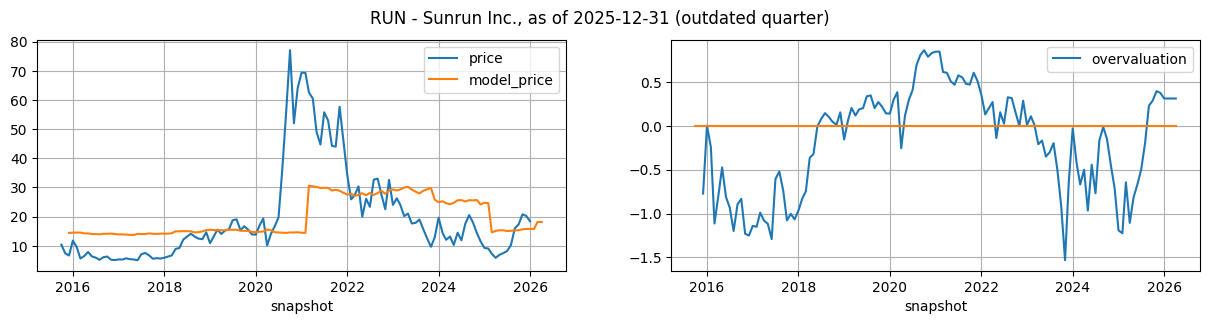

RUN model_price = 3.586273 * (0.952754 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +13.041349


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,price,asmul,cashmul,model,hype,bias,model_price,overvaluation
snapshot,cik,,,,,,,,,,,,,
2025-12-01,0001469367,2025-09-30,RUN,22.225482,19.241580,-0.776747,20.25,0.952754,1.514211,0.757681,3.586273,13.041349,15.758601,0.376075
2026-01-01,0001469367,2025-09-30,RUN,22.225482,19.241580,-0.776747,18.40,0.952754,1.517291,0.755289,3.586273,13.041349,15.750021,0.311865
2026-02-01,0001469367,2025-09-30,RUN,22.225482,19.241580,-0.776747,NaN,0.952754,1.517291,0.755289,3.586273,13.041349,15.750021,0.311865
2026-03-01,0001469367,2025-12-31,RUN,22.610596,19.478112,-0.421440,NaN,0.952754,1.517291,1.424780,3.586273,13.041349,18.150999,0.311865
2026-04-01,0001469367,2025-12-31,RUN,22.610596,19.478112,-0.421440,NaN,0.952754,1.517291,1.424780,3.586273,13.041349,18.150999,0.311865
2026-04-04,0001469367,2025-12-31,RUN,22.610596,19.478112,-0.421440,NaN,0.952754,1.517291,1.424780,3.586273,13.041349,18.150999,0.311865


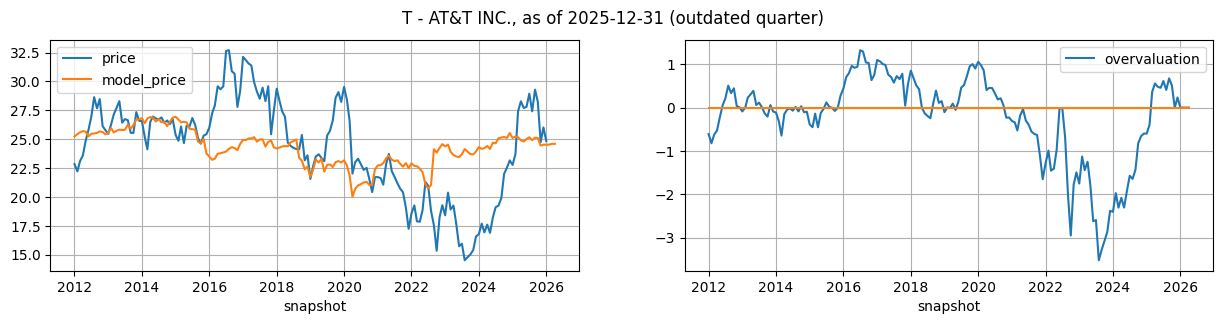

T model_price = 0.040160 * (0.055481 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +32.997399


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,price,asmul,cashmul,model,hype,bias,model_price,overvaluation
snapshot,cik,,,,,,,,,,,,,
2025-12-01,0000732717,2025-09-30,T,423.213,296.458,40.860,26.02,0.055481,1.514211,-211.106956,0.04016,32.997399,24.519366,0.237362
2026-01-01,0000732717,2025-09-30,T,423.213,296.458,40.860,24.84,0.055481,1.517291,-210.981111,0.04016,32.997399,24.524420,0.002749
2026-02-01,0000732717,2025-09-30,T,423.213,296.458,40.860,NaN,0.055481,1.517291,-210.981111,0.04016,32.997399,24.524420,0.002749
2026-03-01,0000732717,2025-12-31,T,420.198,293.707,40.284,NaN,0.055481,1.517291,-209.271347,0.04016,32.997399,24.593084,0.002749
2026-04-01,0000732717,2025-12-31,T,420.198,293.707,40.284,NaN,0.055481,1.517291,-209.271347,0.04016,32.997399,24.593084,0.002749
2026-04-04,0000732717,2025-12-31,T,420.198,293.707,40.284,NaN,0.055481,1.517291,-209.271347,0.04016,32.997399,24.593084,0.002749


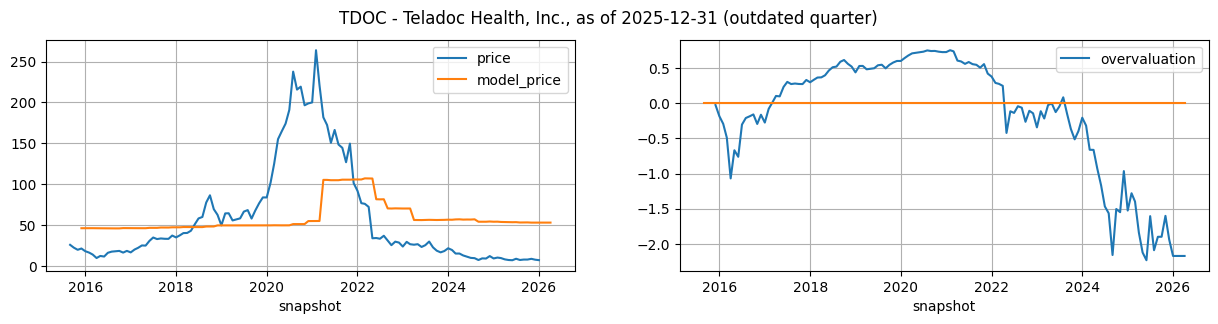

TDOC model_price = 2.975116 * (1.242463 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +45.427382


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,price,asmul,cashmul,model,hype,bias,model_price,overvaluation
snapshot,cik,,,,,,,,,,,,,
2025-12-01,0001477449,2025-09-30,TDOC,2.878547,1.486432,0.292517,7.59,1.242463,1.514211,2.532989,2.975116,45.427382,52.963319,-1.937849
2026-01-01,0001477449,2025-09-30,TDOC,2.878547,1.486432,0.292517,7.00,1.242463,1.517291,2.533890,2.975116,45.427382,52.966000,-2.171782
2026-02-01,0001477449,2025-09-30,TDOC,2.878547,1.486432,0.292517,NaN,1.242463,1.517291,2.533890,2.975116,45.427382,52.966000,-2.171782
2026-03-01,0001477449,2025-12-31,TDOC,2.858300,1.472594,0.294357,NaN,1.242463,1.517291,2.525364,2.975116,45.427382,52.940633,-2.171782
2026-04-01,0001477449,2025-12-31,TDOC,2.858300,1.472594,0.294357,NaN,1.242463,1.517291,2.525364,2.975116,45.427382,52.940633,-2.171782
2026-04-04,0001477449,2025-12-31,TDOC,2.858300,1.472594,0.294357,NaN,1.242463,1.517291,2.525364,2.975116,45.427382,52.940633,-2.171782


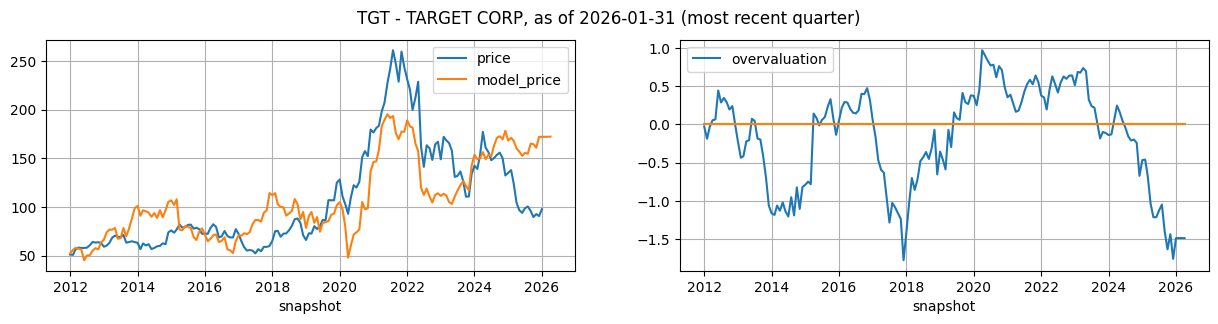

TGT model_price = 4.979999 * (1.605203 * Assets - Liabilities + cashmul * NetCashOperating_ttm) -137.076170


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,price,asmul,cashmul,model,hype,bias,model_price,overvaluation
snapshot,cik,,,,,,,,,,,,,
2025-12-01,0000027419,2025-11-01,TGT,59.991,44.490,6.774,90.62,1.605202,1.514211,62.064964,4.979999,-137.07617,172.007301,-1.757962
2026-01-01,0000027419,2025-11-01,TGT,59.991,44.490,6.774,97.75,1.605202,1.517291,62.085827,4.979999,-137.07617,172.111200,-1.486991
2026-02-01,0000027419,2025-11-01,TGT,59.991,44.490,6.774,NaN,1.605202,1.517291,62.085827,4.979999,-137.07617,172.111200,-1.486991
2026-03-01,0000027419,2025-11-01,TGT,59.991,44.490,6.774,NaN,1.605202,1.517291,62.085827,4.979999,-137.07617,172.111200,-1.486991
2026-04-01,0000027419,2026-01-31,TGT,59.490,43.325,6.562,NaN,1.605202,1.517291,62.124955,4.979999,-137.07617,172.306057,-1.486991
2026-04-04,0000027419,2026-01-31,TGT,59.490,43.325,6.562,NaN,1.605202,1.517291,62.124955,4.979999,-137.07617,172.306057,-1.486991


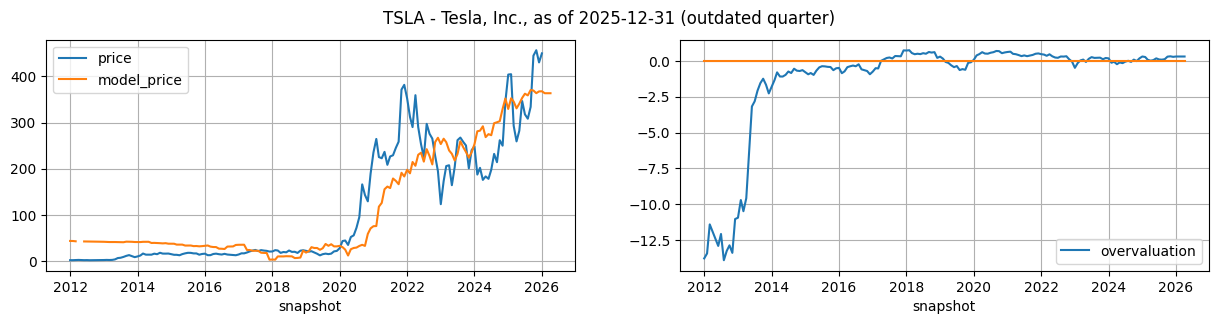

TSLA model_price = 5.615444 * (0.656925 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +42.034498


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,price,asmul,cashmul,model,hype,bias,model_price,overvaluation
snapshot,cik,,,,,,,,,,,,,
2025-12-01,0001318605,2025-09-30,TSLA,133.735,53.765,15.748,430.17,0.656925,1.514211,57.934686,5.615444,42.034498,367.363479,0.275059
2026-01-01,0001318605,2025-09-30,TSLA,133.735,53.765,15.748,449.72,0.656925,1.517291,57.983188,5.615444,42.034498,367.635840,0.298298
2026-02-01,0001318605,2025-12-31,TSLA,137.806,55.669,14.747,NaN,0.656925,1.517291,57.234722,5.615444,42.034498,363.432873,0.298298
2026-03-01,0001318605,2025-12-31,TSLA,137.806,55.669,14.747,NaN,0.656925,1.517291,57.234722,5.615444,42.034498,363.432873,0.298298
2026-04-01,0001318605,2025-12-31,TSLA,137.806,55.669,14.747,NaN,0.656925,1.517291,57.234722,5.615444,42.034498,363.432873,0.298298
2026-04-04,0001318605,2025-12-31,TSLA,137.806,55.669,14.747,NaN,0.656925,1.517291,57.234722,5.615444,42.034498,363.432873,0.298298


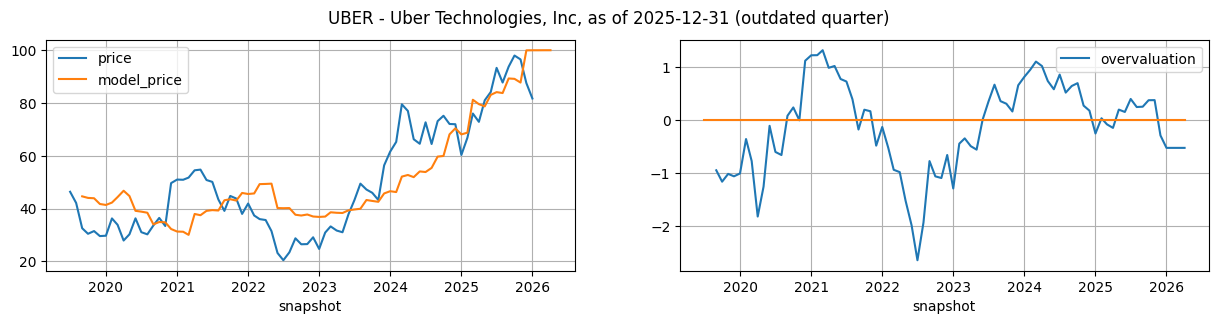

UBER model_price = 1.336906 * (1.398577 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +10.413045


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,price,asmul,cashmul,model,hype,bias,model_price,overvaluation
snapshot,cik,,,,,,,,,,,,,
2025-12-01,0001543151,2025-09-30,UBER,63.344,35.210,8.966,87.54,1.398577,1.514211,66.957860,1.336906,10.413045,99.929394,-0.285207
2026-01-01,0001543151,2025-09-30,UBER,63.344,35.210,8.966,81.71,1.398577,1.517291,66.985474,1.336906,10.413045,99.966312,-0.520097
2026-02-01,0001543151,2025-09-30,UBER,63.344,35.210,8.966,NaN,1.398577,1.517291,66.985474,1.336906,10.413045,99.966312,-0.520097
2026-03-01,0001543151,2025-12-31,UBER,61.802,34.761,10.099,NaN,1.398577,1.517291,66.996960,1.336906,10.413045,99.981666,-0.520097
2026-04-01,0001543151,2025-12-31,UBER,61.802,34.761,10.099,NaN,1.398577,1.517291,66.996960,1.336906,10.413045,99.981666,-0.520097
2026-04-04,0001543151,2025-12-31,UBER,61.802,34.761,10.099,NaN,1.398577,1.517291,66.996960,1.336906,10.413045,99.981666,-0.520097


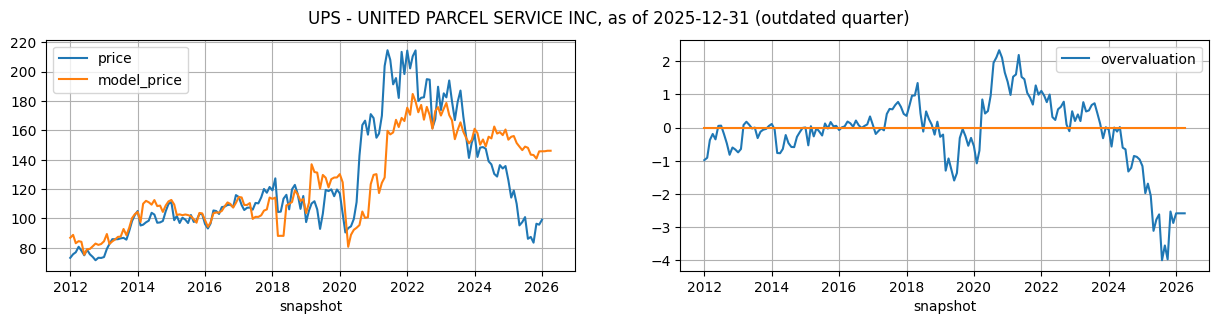

UPS model_price = 2.708491 * (0.847440 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +97.657273


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,price,asmul,cashmul,model,hype,bias,model_price,overvaluation
snapshot,cik,,,,,,,,,,,,,
2025-12-01,0001090727,2025-09-30,UPS,71.392,55.569,8.463,95.79,0.84744,1.514211,17.746191,2.708491,97.657273,145.722679,-2.871311
2026-01-01,0001090727,2025-09-30,UPS,71.392,55.569,8.463,99.19,0.84744,1.517291,17.772256,2.708491,97.657273,145.793276,-2.580289
2026-02-01,0001090727,2025-09-30,UPS,71.392,55.569,8.463,NaN,0.84744,1.517291,17.772256,2.708491,97.657273,145.793276,-2.580289
2026-03-01,0001090727,2025-12-31,UPS,73.090,56.863,8.450,NaN,0.84744,1.517291,17.897484,2.708491,97.657273,146.132456,-2.580289
2026-04-01,0001090727,2025-12-31,UPS,73.090,56.863,8.450,NaN,0.84744,1.517291,17.897484,2.708491,97.657273,146.132456,-2.580289
2026-04-04,0001090727,2025-12-31,UPS,73.090,56.863,8.450,NaN,0.84744,1.517291,17.897484,2.708491,97.657273,146.132456,-2.580289


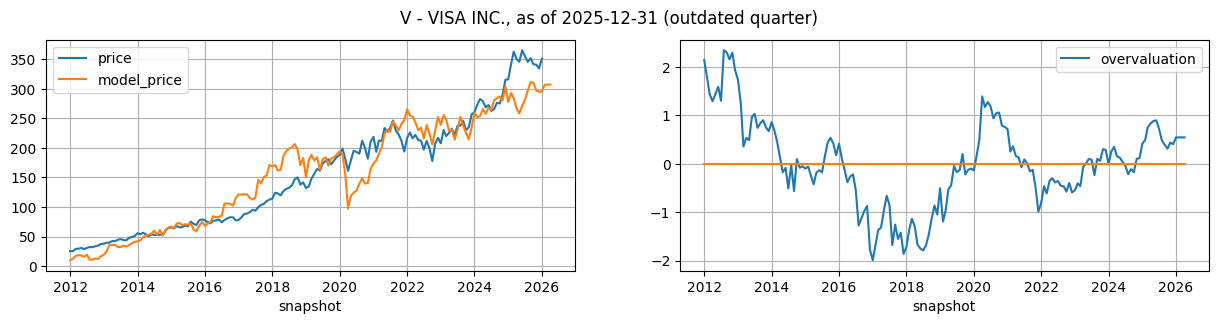

V model_price = 4.644359 * (1.158391 * Assets - Liabilities + cashmul * NetCashOperating_ttm) -116.541262


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,price,asmul,cashmul,model,hype,bias,model_price,overvaluation
snapshot,cik,,,,,,,,,,,,,
2025-12-01,0001403161,2025-09-30,V,99.627,61.718,23.059,334.44,1.158391,1.514211,88.605222,4.644359,-116.541262,294.973203,0.405285
2026-01-01,0001403161,2025-09-30,V,99.627,61.718,23.059,350.71,1.158391,1.517291,88.676241,4.644359,-116.541262,295.303042,0.547409
2026-02-01,0001403161,2025-12-31,V,96.814,58.037,24.443,NaN,1.158391,1.517291,91.198617,4.644359,-116.541262,307.017863,0.547409
2026-03-01,0001403161,2025-12-31,V,96.814,58.037,24.443,NaN,1.158391,1.517291,91.198617,4.644359,-116.541262,307.017863,0.547409
2026-04-01,0001403161,2025-12-31,V,96.814,58.037,24.443,NaN,1.158391,1.517291,91.198617,4.644359,-116.541262,307.017863,0.547409
2026-04-04,0001403161,2025-12-31,V,96.814,58.037,24.443,NaN,1.158391,1.517291,91.198617,4.644359,-116.541262,307.017863,0.547409


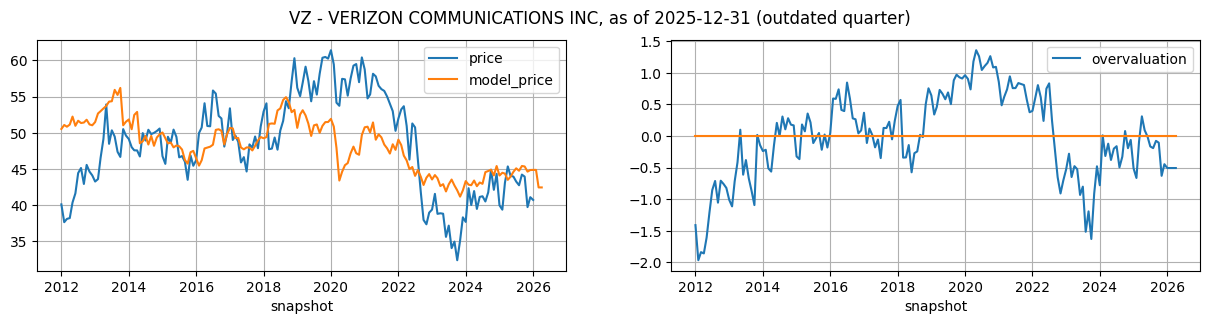

VZ model_price = 0.133924 * (0.029626 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +73.287305


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,price,asmul,cashmul,model,hype,bias,model_price,overvaluation
snapshot,cik,,,,,,,,,,,,,
2025-12-01,0000732712,2025-09-30,VZ,388.331,281.986,38.455,41.11,0.029626,1.514211,-212.252166,0.133924,73.287305,44.861730,-0.446780
2026-01-01,0000732712,2025-09-30,VZ,388.331,281.986,38.455,40.73,0.029626,1.517291,-212.133729,0.133924,73.287305,44.877592,-0.507355
2026-02-01,0000732712,2025-09-30,VZ,388.331,281.986,38.455,NaN,0.029626,1.517291,-212.133729,0.133924,73.287305,44.877592,-0.507355
2026-03-01,0000732712,2025-12-31,VZ,404.258,298.517,37.137,NaN,0.029626,1.517291,-230.192658,0.133924,73.287305,42.459075,-0.507355
2026-04-01,0000732712,2025-12-31,VZ,404.258,298.517,37.137,NaN,0.029626,1.517291,-230.192658,0.133924,73.287305,42.459075,-0.507355
2026-04-04,0000732712,2025-12-31,VZ,404.258,298.517,37.137,NaN,0.029626,1.517291,-230.192658,0.133924,73.287305,42.459075,-0.507355


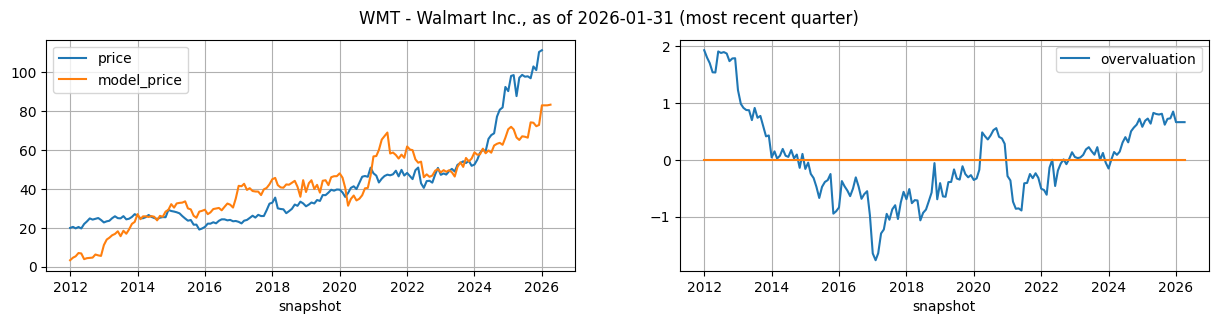

WMT model_price = 0.391285 * (1.890564 * Assets - Liabilities + cashmul * NetCashOperating_ttm) -79.480084


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,price,asmul,cashmul,model,hype,bias,model_price,overvaluation
snapshot,cik,,,,,,,,,,,,,
2025-12-01,0000104169,2025-07-31,WMT,270.837,180.727,38.438,110.51,1.890564,1.514211,389.511042,0.391285,-79.480084,72.929723,0.850207
2026-01-01,0000104169,2025-10-31,WMT,288.655,192.561,40.977,111.41,1.890564,1.517291,415.333905,0.391285,-79.480084,83.033821,0.663811
2026-02-01,0000104169,2025-10-31,WMT,288.655,192.561,40.977,NaN,1.890564,1.517291,415.333905,0.391285,-79.480084,83.033821,0.663811
2026-03-01,0000104169,2025-10-31,WMT,288.655,192.561,40.977,NaN,1.890564,1.517291,415.333905,0.391285,-79.480084,83.033821,0.663811
2026-04-01,0000104169,2026-01-31,WMT,284.668,185.051,41.565,NaN,1.890564,1.517291,416.198392,0.391285,-79.480084,83.372082,0.663811
2026-04-04,0000104169,2026-01-31,WMT,284.668,185.051,41.565,NaN,1.890564,1.517291,416.198392,0.391285,-79.480084,83.372082,0.663811


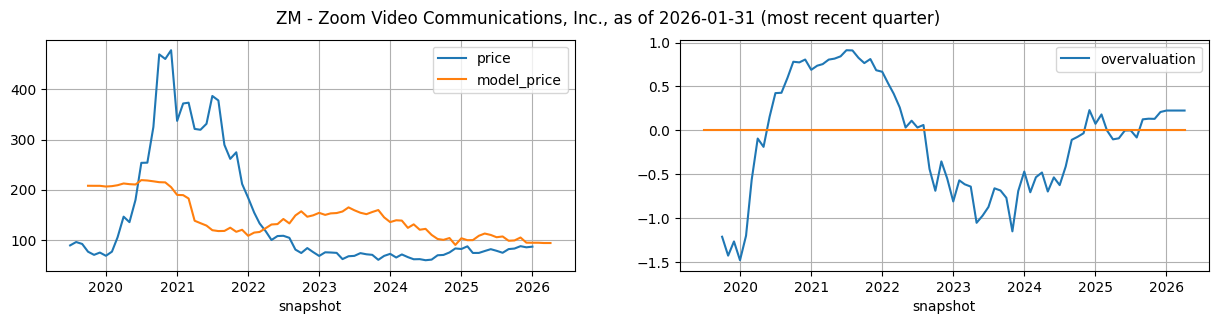

ZM model_price = -25.656388 * (0.309192 * Assets - Liabilities + cashmul * NetCashOperating_ttm) +210.607094


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,price,asmul,cashmul,model,hype,bias,model_price,overvaluation
snapshot,cik,,,,,,,,,,,,,
2025-12-01,0001585521,2025-10-31,ZM,11.390811,2.103971,2.059093,84.96,0.309192,1.514211,4.535881,-25.656388,210.607094,94.232766,0.209405
2026-01-01,0001585521,2025-10-31,ZM,11.390811,2.103971,2.059093,86.29,0.309192,1.517291,4.542223,-25.656388,210.607094,94.070059,0.226072
2026-02-01,0001585521,2025-10-31,ZM,11.390811,2.103971,2.059093,NaN,0.309192,1.517291,4.542223,-25.656388,210.607094,94.070059,0.226072
2026-03-01,0001585521,2026-01-31,ZM,11.960416,2.152158,1.989048,NaN,0.309192,1.517291,4.563875,-25.656388,210.607094,93.514551,0.226072
2026-04-01,0001585521,2026-01-31,ZM,11.960416,2.152158,1.989048,NaN,0.309192,1.517291,4.563875,-25.656388,210.607094,93.514551,0.226072
2026-04-04,0001585521,2026-01-31,ZM,11.960416,2.152158,1.989048,NaN,0.309192,1.517291,4.563875,-25.656388,210.607094,93.514551,0.226072


In [17]:
sample_tickers = ["AAPL","ADBE","ADSK","AMD","AMZN","BYND","CAT","COIN","COST","CRSR","CSCO",
                "DIS","ENPH","F","FDX","FSLR","GM","GME","GOOG","GPRO","IBM","ILMN","INTC","IRBT","JNJ","KO"
                "LYFT","META","MMM","MRNA","MSFT","MU","NFLX","NKE","NVDA","ORCL","PFE","PINS","PLTR","PTON","PYPL",
                "ROKU","RUN","T","TDOC","TGT","TLRY","TSLA","UBER","UPS","V","VZ","WMT","ZM"]

market_median_asmul = result['asmul'].groupby(by=['snapshot']).median().rename('market_median_asmul')

def plot_ticker(a_group):
    (ticker, cik), df = a_group
    try:
        name = tickers.loc[cik]['name']
    except:
        name = ""

    df = df.reset_index().set_index('snapshot')

    # The asset and cash multipliers are not available for the most recent snapshots,
    # which are not part of the stock prices dataset.
    # We use the last available cash multiplier for the model price calculation
    df['asmul'] = df['asmul'].interpolate()
    df['cashmul'] = df['cashmul'].interpolate()
    df['model'] = df['asmul'] * df['Assets'] - df['Liabilities'] + df['cashmul']*df['NetCashOperating_ttm']
    df['model_price'] = df['model'] * df['hype'] + df['bias']

    # We use the scaled ratio of model price to actual price as overvaluation metric.
    scaler = preprocessing.RobustScaler()
    df['overvaluation'] = (df['model_price']/df['price']).interpolate()
    df['overvaluation'] = -1 * scaler.fit_transform(df['overvaluation'].to_frame())

    months_since_last_report = (datetime.today() - pd.to_datetime(df['date'].max())) / timedelta(days=30)
    caption = f"{ticker} - {name}"
    caption += f", as of {df['date'].max()} ({"most recent" if months_since_last_report<3 else "outdated"} quarter)"
    
    # Display two plots side-by-side: of the price & fair-price and of the scaled overvaluation estimate.
    fig, (ax1, ax2) = plt.subplots(1,2)
    fig.suptitle(caption)
    fig.set_size_inches(15,5)
    df[['price','model_price']].plot(ax=ax1, grid=True, legend=True)
    df['overvaluation'].plot(ax=ax2, grid=True, legend=True, figsize=(15,3))
    pd.Series([0.0]*len(df.index),index=df.index).plot(ax=ax2,grid=True)
    plt.show()

    # Here we spell out our pricing model explicitly
    print("{} model_price = {:.6f} * ({:.6f} * Assets - Liabilities + cashmul * NetCashOperating_ttm) {}{:.6f}".format(
        ticker, df['hype'].mean(), df['asmul'].mean(),
        "+" if df['bias'].mean() >= 0 else "", df['bias'].mean()
    ))

    # Display a few most recent records from the result set
    df = df.reset_index().set_index(['snapshot','cik'])
    display(df.tail(6))

    return df

plot_output = pd.concat(list(map(plot_ticker, 
                                 result[result['ticker'].isin(sample_tickers)].groupby(by=['ticker','cik']))))

The model has a lot of room for improvement. It is easy to notice that for some stocks it produces anomalies that should be investigated further. They are probably caused by shifting corporate accounting practices over time, or there could be logical errors in the processing pipeline, which produces the SEC fundamentals dataset.

The biggest advantage of the model, however, is that its results are completely explainable.

In [18]:
# Reality check for our fair price calculation: compute its correlation with the actual prices
print(plot_output[['price','model_price']].corr())
# Sample data
plot_output[plot_output['ticker']=='VZ']

                price  model_price
price        1.000000     0.918881
model_price  0.918881     1.000000


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,price,asmul,cashmul,model,hype,bias,model_price,overvaluation
snapshot,cik,,,,,,,,,,,,,
2012-01-01,0000732712,2011-09-30,VZ,228.032,140.517,29.761,40.12,0.029626,-1.215230,-169.927684,0.133924,73.287305,50.529978,-1.410713
2012-02-01,0000732712,2011-09-30,VZ,228.032,140.517,29.761,37.66,0.029626,-1.077360,-165.824547,0.133924,73.287305,51.079485,-1.965781
2012-03-01,0000732712,2011-12-31,VZ,230.461,144.553,29.780,38.11,0.029626,-1.003307,-167.603754,0.133924,73.287305,50.841207,-1.838175
2012-04-01,0000732712,2011-12-31,VZ,230.461,144.553,29.780,38.23,0.029626,-0.929663,-165.410633,0.133924,73.287305,51.134917,-1.858204
2012-05-01,0000732712,2012-03-31,VZ,222.921,134.500,30.702,40.38,0.029626,-0.953807,-157.179445,0.133924,73.287305,52.237268,-1.606532
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-01-01,0000732712,2025-09-30,VZ,388.331,281.986,38.455,40.73,0.029626,1.517291,-212.133729,0.133924,73.287305,44.877592,-0.507355
2026-02-01,0000732712,2025-09-30,VZ,388.331,281.986,38.455,NaN,0.029626,1.517291,-212.133729,0.133924,73.287305,44.877592,-0.507355
2026-03-01,0000732712,2025-12-31,VZ,404.258,298.517,37.137,NaN,0.029626,1.517291,-230.192658,0.133924,73.287305,42.459075,-0.507355


All overvaluation sequences are scaled, therefore directly comparable, so we can plot them together. An interesting observaton to be made here is, that the magnitudes of overvaluation and undervaluation are not symmetrical. I.e., when stocks are undervalued, they tend to be undervalued deeper, than when they are overvalued. Maybe this is due to some unidentified bias in my model, rather than a market fact.

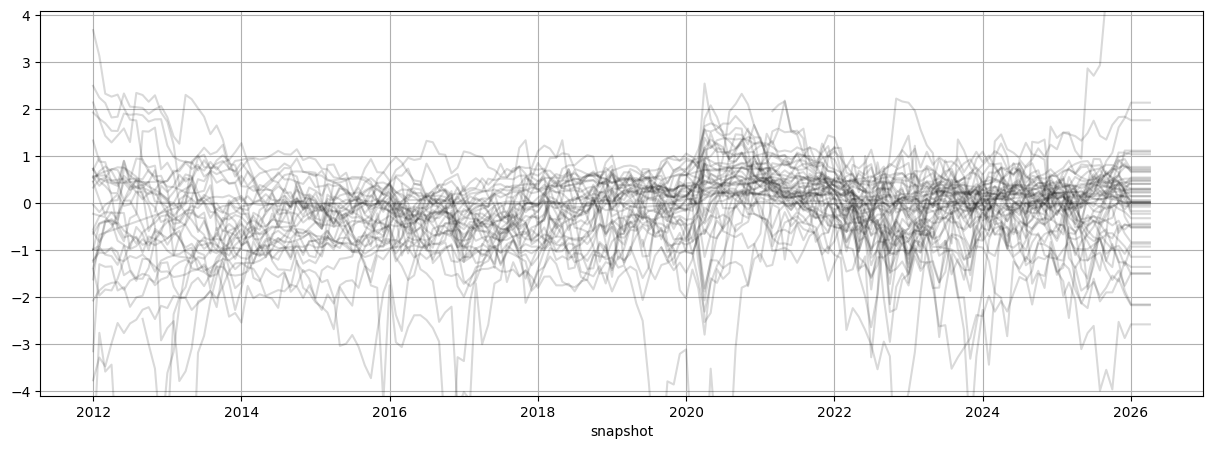

In [19]:
pd.pivot_table(plot_output, index='snapshot', columns='ticker', values='overvaluation').plot(
    grid=True, legend=False, c='black', alpha=0.15, figsize=(15,5),ylim=(-4.1,4.1))
plt.show()

In [20]:
print('Done without errors')

Done without errors


DISCLAIMER: The results of this model **must not** in any way be interpreted as financial advice. It is intended for research purposes only and no investment decisions must be made based on it.